<a href="https://colab.research.google.com/github/mins6871/design-project/blob/main/zip%ED%8C%8C%EC%9D%BC_%EA%B2%BD%EB%A1%9C2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# YOLOv8을 사용하기 위한 ultralytics 라이브러리 설치
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 82.9 MB/s eta 0:00:00


In [2]:
import zipfile
import os
import glob
import shutil
import yaml

master_dir = '/content/merged_dataset'
splits = ['train', 'valid', 'test']

# 1. 꼬임 방지를 위해 기존에 만든 병합 폴더가 있다면 완전 삭제 후 초기화
if os.path.exists(master_dir):
    shutil.rmtree(master_dir)

for split in splits:
    os.makedirs(f'{master_dir}/{split}/images', exist_ok=True)
    os.makedirs(f'{master_dir}/{split}/labels', exist_ok=True)

zip_files = glob.glob('/content/*.zip')

if not zip_files:
    print("🚨 [오류] 업로드된 zip 파일이 없습니다.")
else:
    print(f"📦 총 {len(zip_files)}개의 zip 파일을 병합합니다...")
    global_classes = []
    zip_data = []

    # 1단계: 모든 ZIP 파일의 객체 종류(클래스)를 영리하게 하나로 합치기
    for idx, zf in enumerate(zip_files):
        folder_name = zf.replace('.zip', '')
        with zipfile.ZipFile(zf, 'r') as zip_ref:
            zip_ref.extractall(folder_name)

        yaml_paths = glob.glob(f'{folder_name}/**/data.yaml', recursive=True)
        local_classes = []
        if yaml_paths:
            with open(yaml_paths[0], 'r', encoding='utf-8') as f:
                data = yaml.safe_load(f)
                local_classes = data.get('names', [])
                if isinstance(local_classes, dict):
                    local_classes = list(local_classes.values())

                # 아직 등록 안 된 새로운 객체 종류라면 리스트에 추가
                for cls in local_classes:
                    if cls not in global_classes:
                        global_classes.append(cls)

        # 이름 충돌 방지를 위해 각 zip 파일마다 접두어(ds0_, ds1_ 등) 생성
        zip_data.append((folder_name, local_classes, f"ds{idx}_"))

    print(f"🎯 전체 통합된 객체 종류 ({len(global_classes)}개): {global_classes}")

    # 2단계: 이미지 덮어쓰기 방지 & 라벨 번호(인덱스) 재조정하여 복사
    for folder_name, local_classes, prefix in zip_data:
        for split in splits:
            img_path = f'{folder_name}/{split}/images'
            lbl_path = f'{folder_name}/{split}/labels'

            if os.path.exists(img_path):
                for img_file in os.listdir(img_path):
                    # 1. 이미지 복사 (이름 앞에 ds0_ 등을 붙여서 덮어쓰기 방지)
                    src_img = os.path.join(img_path, img_file)
                    dst_img = os.path.join(f'{master_dir}/{split}/images/', prefix + img_file)
                    shutil.copy(src_img, dst_img)

                    # 2. 해당 이미지의 라벨 파일 찾기 (.txt)
                    lbl_file = os.path.splitext(img_file)[0] + '.txt'
                    src_lbl = os.path.join(lbl_path, lbl_file)
                    dst_lbl = os.path.join(f'{master_dir}/{split}/labels/', prefix + lbl_file)

                    if os.path.exists(src_lbl):
                        # 라벨 번호 변환해서 새 파일로 저장 (핵심 해결 로직)
                        with open(src_lbl, 'r') as f_in, open(dst_lbl, 'w') as f_out:
                            for line in f_in:
                                parts = line.strip().split()
                                if not parts: continue

                                local_idx = int(parts[0])
                                if local_idx < len(local_classes):
                                    cls_name = local_classes[local_idx]
                                    global_idx = global_classes.index(cls_name) # 통합 번호로 변경!
                                    parts[0] = str(global_idx)
                                    f_out.write(' '.join(parts) + '\n')
                    else:
                        # 배경(Background) 이미지인 경우 빈 라벨 파일 생성
                        open(dst_lbl, 'w').close()

    # 3단계: 새로운 완벽한 마스터 data.yaml 생성
    yaml_content = {
        'train': f'{master_dir}/train/images',
        'val': f'{master_dir}/valid/images',
    }

    # 에러 방지 안전장치: valid 폴더가 비어있으면 train을 대신 쓰도록 설정
    if len(os.listdir(f'{master_dir}/valid/images')) == 0:
         yaml_content['val'] = f'{master_dir}/train/images'

    if len(os.listdir(f'{master_dir}/test/images')) > 0:
        yaml_content['test'] = f'{master_dir}/test/images'

    yaml_content['nc'] = len(global_classes)
    yaml_content['names'] = global_classes

    with open(f'{master_dir}/data.yaml', 'w', encoding='utf-8') as f:
        yaml.dump(yaml_content, f, sort_keys=False, allow_unicode=True)

    print("\n✅ 데이터가 완벽하게 병합되었습니다! 누락된 객체 없이 모두 합쳐졌습니다.")

📦 총 9개의 zip 파일을 병합합니다...
🎯 전체 통합된 객체 종류 (9개): ['cap', 'fet', 'led', 'object', 'res', 'jump', 'mos', 'wire', 'short-wire']

✅ 데이터가 완벽하게 병합되었습니다! 누락된 객체 없이 모두 합쳐졌습니다.


In [4]:
from ultralytics import YOLO

# 모델 불러오기
model = YOLO('yolov8n.pt')

# 통합된 데이터셋으로 모델 학습
print("🚀 학습을 시작합니다. 에포크(Epoch)가 끝날 때까지 기다려주세요...")
results = model.train(data='/content/merged_dataset/data.yaml',
                      epochs=100,  # 필요에 따라 학습 횟수 조정
                      imgsz=640,
                      plots=True)
print("🎉 학습이 완료되었습니다!")

🚀 학습을 시작합니다. 에포크(Epoch)가 끝날 때까지 기다려주세요...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, o

✅ 모델 준비 완료!

👇 아래의 [파일 선택] 버튼을 눌러 테스트할 이미지 파일(.jpg, .png 등)을 골라주세요!


Saving report.jpg to report (1).jpg

✅ 'report (1).jpg' 업로드 완료! 분석을 시작합니다...


image 1/1 /content/report (1).jpg: 640x480 2 caps, 1 fet, 2 leds, 5 ress, 7.3ms
Speed: 3.3ms preprocess, 7.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)
🎯 총 인식된 객체 개수: 10개

--- 📍 상세 위치 및 정보 ---
[1] fet
    - 확률: 95.9%
    - 위치: X(1734 ~ 1936), Y(1612 ~ 1962)

[2] cap
    - 확률: 95.4%
    - 위치: X(1974 ~ 2298), Y(2413 ~ 2707)

[3] cap
    - 확률: 95.0%
    - 위치: X(1330 ~ 1634), Y(2827 ~ 3152)

[4] res
    - 확률: 86.5%
    - 위치: X(1635 ~ 1879), Y(627 ~ 713)

[5] res
    - 확률: 79.8%
    - 위치: X(1648 ~ 1861), Y(1345 ~ 1423)

[6] res
    - 확률: 72.3%
    - 위치: X(1775 ~ 2000), Y(2905 ~ 3012)

[7] led
    - 확률: 67.9%
    - 위치: X(1311 ~ 1466), Y(2385 ~ 2564)

[8] res
    - 확률: 65.7%
    - 위치: X(1683 ~ 1938), Y(932 ~ 1019)

[9] res
    - 확률: 64.9%
    - 위치: X(1700 ~ 1895), Y(1184 ~ 1261)

[10] led
    - 확률: 61.6%
    - 위치: X(1781 ~ 1958), Y(2079 ~ 2243)



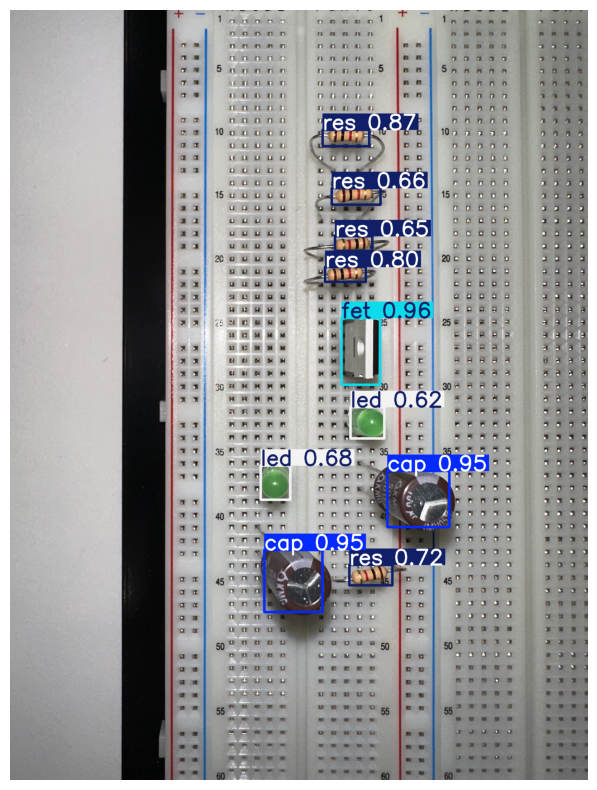

In [55]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files # 파일 업로드 기능 추가

# 1. 가장 최근에 학습 완료된 모델 자동으로 찾기
weight_paths = glob.glob('/content/runs/detect/*/weights/best.pt')

if not weight_paths:
    print("🚨 [오류] 학습된 모델을 찾을 수 없습니다. 학습이 완료되었는지 확인해 주세요.")
else:
    latest_weight_path = max(weight_paths, key=os.path.getctime)
    trained_model = YOLO(latest_weight_path)
    print("✅ 모델 준비 완료!\n")

    # 2. 파일 업로드 버튼 띄우기
    print("👇 아래의 [파일 선택] 버튼을 눌러 테스트할 이미지 파일(.jpg, .png 등)을 골라주세요!")
    uploaded = files.upload()

    if not uploaded:
        print("🚨 업로드된 파일이 없습니다. 코드를 다시 실행해주세요.")
    else:
        # 3. 업로드한 파일 이름 가져오기
        filename = list(uploaded.keys())[0]
        test_image_path = f'/content/{filename}'
        print(f"\n✅ '{filename}' 업로드 완료! 분석을 시작합니다...\n")

        # 4. 추론 실행
        results = trained_model(test_image_path)
        result = results[0]

        # 5. 개수, 정확도, 위치 정보 출력
        detected_count = len(result.boxes)
        print(f"🎯 총 인식된 객체 개수: {detected_count}개\n")

        print("--- 📍 상세 위치 및 정보 ---")
        for i, box in enumerate(result.boxes):
            class_id = int(box.cls[0].item())
            class_name = trained_model.names[class_id]
            confidence = box.conf[0].item()
            xmin, ymin, xmax, ymax = map(int, box.xyxy[0].tolist())

            print(f"[{i+1}] {class_name}")
            print(f"    - 확률: {confidence*100:.1f}%")
            print(f"    - 위치: X({xmin} ~ {xmax}), Y({ymin} ~ {ymax})\n")

        # 6. 결과 시각화
        res_img = result.plot()
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(res_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

In [56]:
import cv2
import math
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files
import collections

# --- 1. 모델 자동 로드 ---
weight_paths = glob.glob('/content/runs/detect/*/weights/best.pt')
if not weight_paths:
    print("🚨 [오류] 학습된 모델을 찾을 수 없습니다. 학습 완료 후 진행해주세요.")
else:
    latest_weight_path = max(weight_paths, key=os.path.getctime)
    trained_model = YOLO(latest_weight_path)
    print("✅ 모델 로드 완료!")

    # --- 2. 이미지 파일 업로드 ---
    print("\n👇 아래의 [파일 선택] 버튼을 눌러 소자가 꽂힌 빵판 사진을 업로드해주세요!")
    uploaded = files.upload()

    if not uploaded:
        print("🚨 업로드된 파일이 없습니다. 코드를 다시 실행해주세요.")
    else:
        # 업로드된 파일 이름 가져오기
        image_path = list(uploaded.keys())[0]
        print(f"\n✅ '{image_path}' 분석을 시작합니다...\n")

        img = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # --- 3. OpenCV로 브레드보드 모든 구멍(Hole) 찾기 ---
        # HoughCircles 파라미터는 업로드하신 사진의 해상도나 밝기에 따라 튜닝이 필요할 수 있습니다.
        # minDist(구멍간 최소 거리), param2(동그라미 인식 임계값), minRadius/maxRadius 조절
        circles = cv2.HoughCircles(
            gray, cv2.HOUGH_GRADIENT, dp=1.1, minDist=20,
            param1=50, param2=25, minRadius=5, maxRadius=15
        )

        detected_holes = []
        if circles is not None:
            circles = np.round(circles[0, :]).astype("int")
            for (x, y, r) in circles:
                detected_holes.append({'px_x': x, 'px_y': y})

        print(f"🎯 OpenCV가 인식한 빵판 구멍 개수: {len(detected_holes)}개 (전원부 포함)")

        if len(detected_holes) < 50:
             print("🚨 [오류] 구멍 인식이 충분하지 않습니다. 사진 품질을 확인하거나 OpenCV 파라미터를 조정해주세요.")
        else:
            # --- 4. [핵심 로직] 메인 5x30 구멍에 논리적 주소(A1 ~ J30) 매핑하기 ---
            # 전원부(가장 상/하단 긴 줄)는 전압이 달라 혼동을 주므로 제외하고 메인 영역만 추출합니다.

            # y좌표(상하) 기준 정렬
            sorted_by_y = sorted(detected_holes, key=lambda h: h['px_y'])
            y_coords = np.array([h['px_y'] for h in sorted_by_y])

            # 간단한 클러스터링: y좌표 격차가 큰 곳을 찾아 전원부와 메인 영역 분리 (수직 촬영 가정)
            y_diffs = np.diff(y_coords)
            mean_diff = np.mean(y_diffs)

            # 상단 전원부 제외 (y좌표 촘촘한 상위 그룹 제거)
            main_start_idx = 0
            for i in range(1, len(y_coords)-1):
                 if y_coords[i] - y_coords[0] > mean_diff * 4: # 수직 격차가 확 벌어지는 곳
                      main_start_idx = i
                      break

            # 하단 전원부 제외 (y좌표 격차가 확 벌어지는 하위 그룹 제거)
            main_end_idx = len(y_coords)
            for i in range(len(y_coords)-2, main_start_idx, -1):
                 if y_coords[-1] - y_coords[i] > mean_diff * 4:
                      main_end_idx = i + 1
                      break

            main_area_holes_px = sorted_by_y[main_start_idx:main_end_idx]
            print(f"🎯 메인 영역 구멍 추론 개수: {len(main_area_holes_px)}개")

            # X좌표(좌우) 기준 30개 열로 정렬 및 매핑
            main_area_holes_px.sort(key=lambda h: h['px_x'])

            # x좌표 그룹화 (열 분류)
            num_cols = 30
            cols = []
            if len(main_area_holes_px) > 0:
                curr_col = [main_area_holes_px[0]]
                # 평균 구멍 간격 계산 (x축)
                x_vals = np.array([h['px_x'] for h in main_area_holes_px])
                unique_x, counts = np.unique(x_vals, return_counts=True)
                mean_x_diff = np.mean(np.diff(unique_x)) if len(unique_x) > 1 else 30 # fallback

                col_threshold = mean_x_diff * 0.7 # 열 구분 임계값

                for h in main_area_holes_px[1:]:
                    if h['px_x'] - curr_col[-1]['px_x'] < col_threshold:
                        curr_col.append(h)
                    else:
                        cols.append(curr_col)
                        curr_col = [h]
                cols.append(curr_col) # 마지막 열 추가

            # 찾은 열의 개수가 30개가 안되거나 넘어도, 좌측부터 순서대로 1~30 부여 (현실 타협)
            # 정확도를 높이려면 격자(grid) 모델링이 추가로 필요함

            final_labeled_grid_map = {} # {'C-10': (px_x, px_y)}

            # 행 라벨 (위에서부터 A~E, F~J)
            row_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']

            for col_idx, col_holes in enumerate(cols[:num_cols]): # 최대 30열까지만
                col_num = col_idx + 1 # 1부터 시작하는 열 번호

                # 열 내부에서 Y좌표(상하) 정렬
                col_holes.sort(key=lambda h: h['px_y'])

                # 행 라벨 부여
                # 메인 영역 구멍이 잘 잡혔다면 보통 한 열에 10개가 잡혀야 함.
                # 예외 처리: 구멍이 누락되거나 잘못 잡혀도 순서대로 A~J 부여 (취약점)
                for row_idx, hole in enumerate(col_holes[:10]): # 최대 10행까지만
                     row_letter = row_labels[row_idx]
                     label = f"{row_letter}-{col_num}"
                     final_labeled_grid_map[label] = (hole['px_x'], hole['px_y'])

                     # 시각화: 주소 매핑된 구멍에 빨간색 점 (시각화)
                     cv2.circle(img_rgb, (hole['px_x'], hole['px_y']), 3, (255, 0, 0), -1)

            print(f"✅ 구멍 주소 매핑 완료! 총 {len(final_labeled_grid_map)}개 구멍 주소 확보")
            if len(final_labeled_grid_map) < 150:
                 print("🚨 [경고] 매핑된 주소가 너무 적습니다. OpenCV 파라미터를 조절해주세요.")

            # --- 5. 유클리디안 거리 기반 논리 주소 매핑 함수 ---
            def find_nearest_labeled_hole(target_x, target_y, labeled_grid):
                if not labeled_grid: return None, None

                closest_label = min(labeled_grid.keys(),
                                    key=lambda label: math.hypot(labeled_grid[label][0] - target_x,
                                                                 labeled_grid[label][1] - target_y))
                closest_px = labeled_grid[closest_label]
                return closest_label, closest_px

            # --- 6. YOLO 추론 및 소자 위치 매핑 ---
            results = trained_model(image_path)
            result = results[0]

            print("\n--- 📍 추출된 소자 위치 정보 (연결 추론) ---")
            for i, box in enumerate(result.boxes):
                class_id = int(box.cls[0].item())
                class_name = trained_model.names[class_id]

                # 몸통 박스 좌표 가져오기
                xmin, ymin, xmax, ymax = map(int, box.xyxy[0].tolist())

                # [수학적 가설] 다리는 몸통의 좌측 하단(`xmin`, `ymax`), 우측 하단(`xmax`, `ymax`)에 수직으로 꽂혀있을 것이다!
                pin1_guess_px = (xmin, ymax)
                pin2_guess_px = (xmax, ymax)

                # 가설 픽셀 위치에서 가장 가까운 논리적 주소(A1~J30)와 실제 픽셀 좌표 찾기
                pin1_label, pin1_actual_px = find_nearest_labeled_hole(pin1_guess_px[0], pin1_guess_px[1], final_labeled_grid_map)
                pin2_label, pin2_actual_px = find_nearest_labeled_hole(pin2_guess_px[0], pin2_guess_px[1], final_labeled_grid_map)

                print(f"[{class_name}_{i+1}] 다리 추론 -> {pin1_label} 번 구멍, {pin2_label} 번 구멍에 꽂혔을 확률이 높음")

                # --- 7. 시각화 ---
                # 몸통 박스 그리기 (초록색)
                cv2.rectangle(img_rgb, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
                # 소자 이름 표시
                cv2.putText(img_rgb, f"{class_name}_{i+1}", (xmin, ymin-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

                # 매핑된 구멍 위치 표시 (빨간색 원)
                if pin1_actual_px:
                    cv2.circle(img_rgb, pin1_actual_px, 10, (0, 0, 255), 2)
                    # 추정 다리에서 실제 구멍까지 선 긋기
                    cv2.line(img_rgb, pin1_guess_px, pin1_actual_px, (255, 0, 0), 2)
                if pin2_actual_px:
                    cv2.circle(img_rgb, pin2_actual_px, 10, (0, 0, 255), 2)
                    cv2.line(img_rgb, pin2_guess_px, pin2_actual_px, (255, 0, 0), 2)

            # --- 8. 결과 시각화 ---
            plt.figure(figsize=(15, 15))
            plt.imshow(img_rgb)
            plt.title("Breadboard Hole-Mapping & Component Leg 추론")
            plt.axis('off')
            plt.show()

✅ 모델 로드 완료!

👇 아래의 [파일 선택] 버튼을 눌러 소자가 꽂힌 빵판 사진을 업로드해주세요!


Saving report.jpg to report (2).jpg

✅ 'report (2).jpg' 분석을 시작합니다...

🎯 OpenCV가 인식한 빵판 구멍 개수: 25개 (전원부 포함)
🚨 [오류] 구멍 인식이 충분하지 않습니다. 사진 품질을 확인하거나 OpenCV 파라미터를 조정해주세요.


✅ 그림 파일 로드 완료! (자동 측정된 픽셀 크기: 가로 1697 x 세로 2400)
✅ YOLO 모델 로드 완료!

👇 아래의 [파일 선택] 버튼을 눌러 테스트할 '실제 빵판 사진'을 업로드해주세요!


Saving report.jpg to report (3).jpg

✅ 'report (3).jpg' 분석을 시작합니다...


image 1/1 /content/report (3).jpg: 640x480 2 caps, 1 fet, 2 leds, 5 ress, 7.4ms
Speed: 3.2ms preprocess, 7.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)

--- 📍 도식화 및 데이터 매핑 ---
[fet_1] 그림 좌표 매핑 완료 (추정 핀 위치: (973, 1167), (1086, 1167))
[cap_2] 그림 좌표 매핑 완료 (추정 핀 위치: (1107, 1611), (1289, 1611))
[cap_3] 그림 좌표 매핑 완료 (추정 핀 위치: (746, 1876), (916, 1876))
[res_4] 그림 좌표 매핑 완료 (추정 핀 위치: (917, 424), (1054, 424))
[res_5] 그림 좌표 매핑 완료 (추정 핀 위치: (924, 847), (1044, 847))
[res_6] 그림 좌표 매핑 완료 (추정 핀 위치: (996, 1792), (1122, 1792))
[led_7] 그림 좌표 매핑 완료 (추정 핀 위치: (735, 1526), (822, 1526))
[res_8] 그림 좌표 매핑 완료 (추정 핀 위치: (944, 606), (1087, 606))
[res_9] 그림 좌표 매핑 완료 (추정 핀 위치: (954, 750), (1063, 750))
[led_10] 그림 좌표 매핑 완료 (추정 핀 위치: (999, 1335), (1098, 1335))


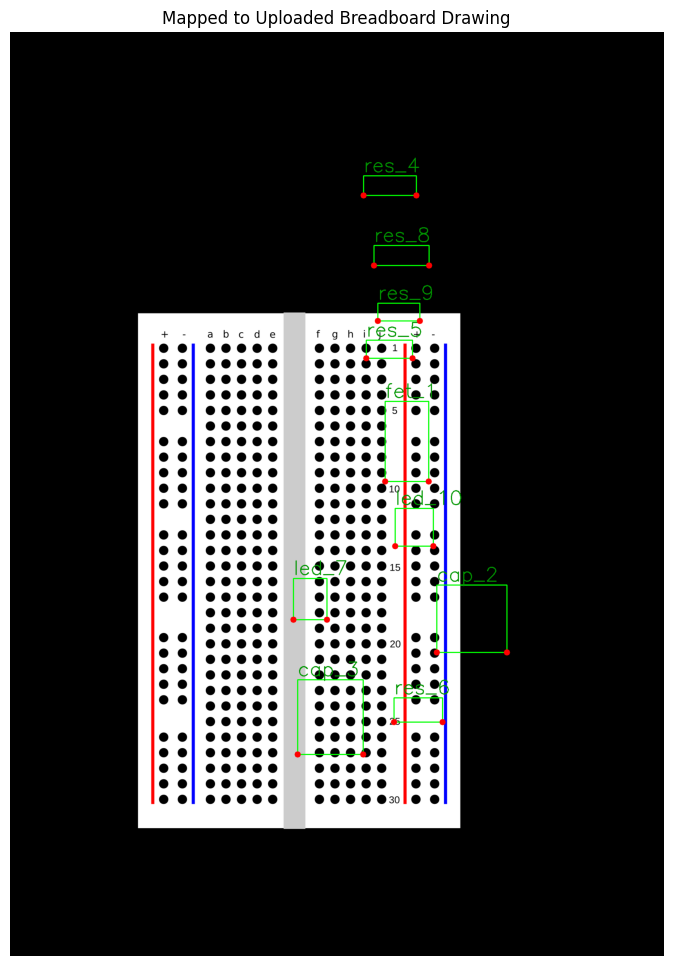


✅ 'output_circuit.fz' 파일이 생성되었습니다. 파일 탐색기에서 다운로드 후 Fritzing에서 수정하세요!


In [57]:
import cv2
import glob
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files
import xml.etree.ElementTree as ET

# --- 1. 깔끔한 빵판 이미지 로드 및 자동 크기 측정 ---
# ✅ 코랩 파일 탐색기에 'clean_breadboard.png' 파일이 업로드되어 있어야 합니다.
CLEAN_BREADBOARD_IMG = '/content/clean_breadboard.png'
cb_canvas = cv2.imread(CLEAN_BREADBOARD_IMG)

if cb_canvas is None:
    print("🚨 [오류] 'clean_breadboard.png' 파일을 찾을 수 없습니다. 왼쪽 폴더에 업로드 했는지 확인해주세요.")
else:
    # 이미지의 [세로, 가로, 채널] 값을 자동으로 가져옵니다.
    CB_HEIGHT, CB_WIDTH, _ = cb_canvas.shape
    print(f"✅ 그림 파일 로드 완료! (자동 측정된 픽셀 크기: 가로 {CB_WIDTH} x 세로 {CB_HEIGHT})")

    # --- 2. 모델 자동 로드 ---
    weight_paths = glob.glob('/content/runs/detect/*/weights/best.pt')
    if not weight_paths:
        print("🚨 [오류] 학습된 YOLO 모델(best.pt)을 찾을 수 없습니다.")
    else:
        latest_weight_path = max(weight_paths, key=os.path.getctime)
        trained_model = YOLO(latest_weight_path)
        print("✅ YOLO 모델 로드 완료!")

        # --- 3. 실제 빵판 사진 업로드 ---
        print("\n👇 아래의 [파일 선택] 버튼을 눌러 테스트할 '실제 빵판 사진'을 업로드해주세요!")
        uploaded = files.upload()

        if not uploaded:
            print("🚨 업로드된 파일이 없습니다. 코드를 다시 실행해주세요.")
        else:
            real_image_path = list(uploaded.keys())[0]
            real_img = cv2.imread(real_image_path)
            real_h, real_w, _ = real_img.shape
            print(f"\n✅ '{real_image_path}' 분석을 시작합니다...\n")

            # --- 4. YOLOv8 추론 ---
            results = trained_model(real_image_path)
            result = results[0]

            cb_canvas_rgb = cv2.cvtColor(cb_canvas, cv2.COLOR_BGR2RGB)

            # --- Fritzing XML 초기화 (뼈대 구성) ---
            root = ET.Element("module", frizzingVersion="0.9.3b", xmlns="")
            instance = ET.SubElement(root, "instance", moduleIdRef="BreadboardModuleID", modelIndex="1", path=":/resources/parts/core/breadboard2.fzp")
            ET.SubElement(instance, "title").text = "Breadboard1"
            views = ET.SubElement(instance, "views")
            ET.SubElement(views, "breadboardView", layer="breadboardbreadboard")
            parts_instances = ET.SubElement(root, "instances")

            print("\n--- 📍 도식화 및 데이터 매핑 ---")
            for i, box in enumerate(result.boxes):
                class_id = int(box.cls[0].item())
                class_name = trained_model.names[class_id]
                xmin, ymin, xmax, ymax = map(int, box.xyxy[0].tolist())

                # --- [핵심] 실제 사진 좌표 -> 자동 측정된 그림 좌표 비율 변환 ---
                rel_xmin, rel_ymin = xmin / real_w, ymin / real_h
                rel_xmax, rel_ymax = xmax / real_w, ymax / real_h

                cb_xmin, cb_ymin = int(rel_xmin * CB_WIDTH), int(rel_ymin * CB_HEIGHT)
                cb_xmax, cb_ymax = int(rel_xmax * CB_WIDTH), int(rel_ymax * CB_HEIGHT)

                # 그림 도화지에 부품 박스(초록색) 그리기
                cv2.rectangle(cb_canvas_rgb, (cb_xmin, cb_ymin), (cb_xmax, cb_ymax), (0, 255, 0), 2)
                # 글씨가 너무 작지 않게 폰트 크기 비율 조정
                cv2.putText(cb_canvas_rgb, f"{class_name}_{i+1}", (cb_xmin, cb_ymin-10), cv2.FONT_HERSHEY_SIMPLEX, CB_WIDTH/1000, (0, 150, 0), 2)

                # 다리 추정 위치 표시 (빨간색 꽉 찬 동그라미)
                pin1_guess_cb = (cb_xmin, cb_ymax)
                pin2_guess_cb = (cb_xmax, cb_ymax)
                cv2.circle(cb_canvas_rgb, pin1_guess_cb, 8, (255, 0, 0), -1)
                cv2.circle(cb_canvas_rgb, pin2_guess_cb, 8, (255, 0, 0), -1)

                print(f"[{class_name}_{i+1}] 그림 좌표 매핑 완료 (추정 핀 위치: {pin1_guess_cb}, {pin2_guess_cb})")

            # --- 5. Fritzing 더미 파일 생성 ---
            tree = ET.ElementTree(root)
            ET.indent(tree, space="  ", level=0)
            output_fz = 'output_circuit.fz'
            tree.write(output_fz, encoding='utf-8', xml_declaration=True)

            # --- 6. 최종 시각화 결과 출력 ---
            plt.figure(figsize=(10, 12)) # 세로로 긴 이미지에 맞게 출력 창 비율 조정
            plt.imshow(cb_canvas_rgb)
            plt.title("Mapped to Uploaded Breadboard Drawing")
            plt.axis('off')
            plt.show()

            print(f"\n✅ '{output_fz}' 파일이 생성되었습니다. 파일 탐색기에서 다운로드 후 Fritzing에서 수정하세요!")

✅ 그림 파일 로드 및 여백 보정 완료! (알맹이 영역 크기: 가로 1358 x 세로 1535)

👇 [파일 선택] 버튼을 눌러 테스트할 '실제 빵판 사진'을 업로드해주세요!


Saving KakaoTalk_20260406_194846366.jpg to KakaoTalk_20260406_194846366 (1).jpg

image 1/1 /content/KakaoTalk_20260406_194846366 (1).jpg: 640x448 1 jump, 1 cap, 1 res, 41.5ms
Speed: 2.4ms preprocess, 41.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 448)

--- 📍 부품 분석 및 지능형 도식화 시작 ---
[JUMP] jump_1 - 가로 방향 인식, 좌/우 핀 배치 완료
[RES] res_2 - 세로 방향 인식, 상/하 핀 배치 완료
[CAP] cap_3 - 가로 방향 인식, 좌/우 핀 배치 완료


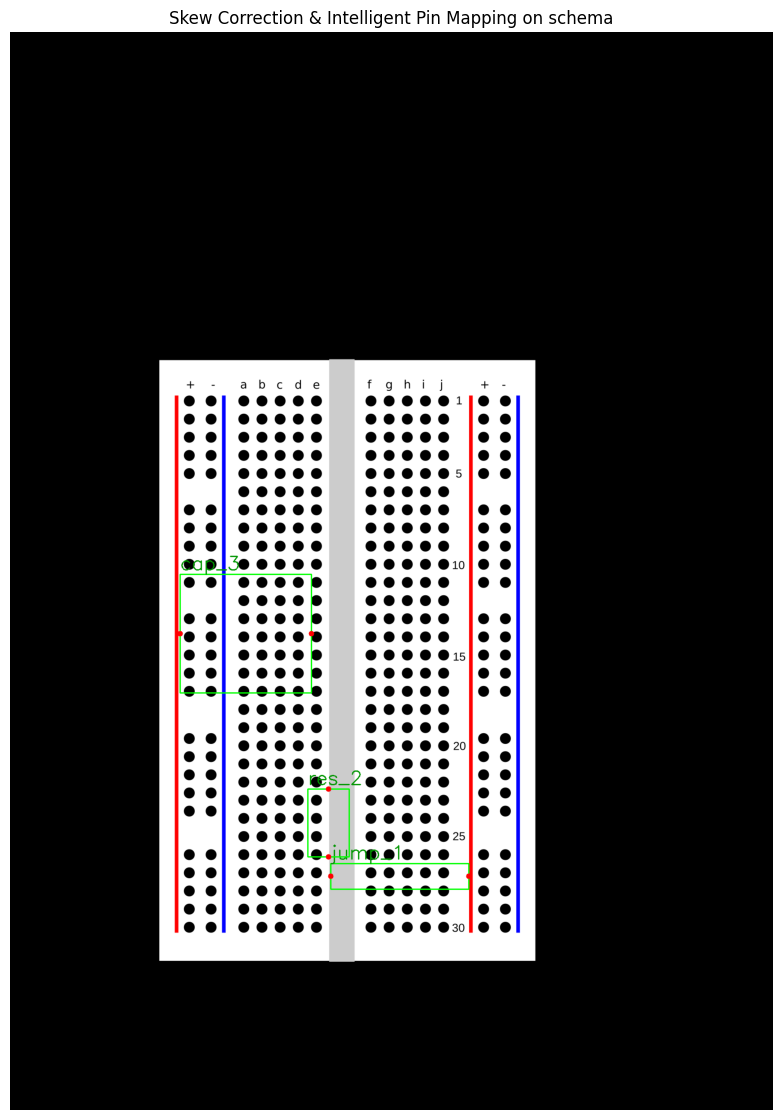

In [ ]:
import cv2
import glob
import os
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files

# --- 1. 깔끔한 빵판 이미지 로드 및 알맹이 영역(ROI) 정밀 재설정 ---
CLEAN_BREADBOARD_IMG = '/content/clean_breadboard.png'
cb_canvas = cv2.imread(CLEAN_BREADBOARD_IMG)

if cb_canvas is None:
    print("🚨 [오류] 'clean_breadboard.png' 파일을 찾을 수 없습니다. 왼쪽 폴더에 업로드 했는지 확인해주세요.")
else:
    CB_HEIGHT, CB_WIDTH, _ = cb_canvas.shape

    # 🌟 [쏠림 해결 - 정밀 좌표 수정]
    # 올려주신 image_0.png를 분석하여 실제 구멍 영역(알맹이)의 비율을 다시 계산했습니다.
    # 오른쪽 위로 쏠리는 것을 막기 위해 왼쪽 시작점(x1)을 대폭 줄이고, 위쪽 시작점(y1)을 대폭 늘렸습니다.
    # 이 수치들은 image_0.png의 수직 비율에 최적화되어 있습니다.
    roi_x1 = int(CB_WIDTH * 0.10)  # [수정] 왼쪽 시작점을 15% -> 10%로 줄여 소자들을 왼쪽으로 이동
    roi_x2 = int(CB_WIDTH * 0.90)  # 오른쪽 끝점을 85% -> 90%로 늘려 전체 폭 확보
    roi_y1 = int(CB_HEIGHT * 0.18) # [수정] 위쪽 시작점을 10% -> 18%로 늘려 소자들을 아래로 이동 (쏠림 해결 핵심)
    roi_y2 = int(CB_HEIGHT * 0.82) # 아래쪽 끝점을 90% -> 82%로 줄여 아래 여백 확보
    roi_w = roi_x2 - roi_x1
    roi_h = roi_y2 - roi_y1
    print(f"✅ 그림 파일 로드 및 여백 보정 완료! (알맹이 영역 크기: 가로 {roi_w} x 세로 {roi_h})")

    # --- 2. 모델 로드 ---
    weight_paths = glob.glob('/content/runs/detect/*/weights/best.pt')
    if not weight_paths:
        print("🚨 [오류] 학습된 YOLO 모델(best.pt)을 찾을 수 없습니다.")
    else:
        latest_weight_path = max(weight_paths, key=os.path.getctime)
        trained_model = YOLO(latest_weight_path)

        # --- 3. 실제 스마트폰 사진 업로드 ---
        print("\n👇 [파일 선택] 버튼을 눌러 테스트할 '실제 빵판 사진'을 업로드해주세요!")
        uploaded = files.upload()

        if uploaded:
            real_image_path = list(uploaded.keys())[0]
            real_img = cv2.imread(real_image_path)
            real_h, real_w, _ = real_img.shape

            # YOLO 추론
            results = trained_model(real_image_path)
            result = results[0]

            cb_canvas_rgb = cv2.cvtColor(cb_canvas, cv2.COLOR_BGR2RGB)

            print("\n--- 📍 부품 분석 및 지능형 도식화 시작 ---")
            for i, box in enumerate(result.boxes):
                # 소자 종류 가져오기 (소문자로 통일)
                class_name = trained_model.names[int(box.cls[0].item())].lower()
                xmin, ymin, xmax, ymax = map(int, box.xyxy[0].tolist())

                # --- 비율 좌표 변환 (정밀 수정된 ROI 영역에 완벽 매핑) ---
                rel_xmin, rel_ymin = xmin / real_w, ymin / real_h
                rel_xmax, rel_ymax = xmax / real_w, ymax / real_h

                # 전체 도화지가 아닌, 빵판 알맹이 영역(ROI)을 기준으로 좌표를 그립니다.
                cb_xmin = roi_x1 + int(rel_xmin * roi_w)
                cb_ymin = roi_y1 + int(rel_ymin * roi_h)
                cb_xmax = roi_x1 + int(rel_xmax * roi_w)
                cb_ymax = roi_y1 + int(rel_ymax * roi_h)

                # 몸통 박스 그리기 (초록색)
                cv2.rectangle(cb_canvas_rgb, (cb_xmin, cb_ymin), (cb_xmax, cb_ymax), (0, 255, 0), 2)
                # 글씨 폰트 크기 비율 조정
                cv2.putText(cb_canvas_rgb, f"{class_name}_{i+1}", (cb_xmin, cb_ymin-10),
                            cv2.FONT_HERSHEY_SIMPLEX, CB_WIDTH/1200, (0, 150, 0), 2)

                # --- [요청 사항] 소자별 지능형 핀(Pin) 위치 매핑 로직 (유지) ---
                pins = []
                box_w = cb_xmax - cb_xmin
                box_h = cb_ymax - cb_ymin

                if class_name in ['fet', 'mosfet']:
                    # FET: 맨 위(Source, 파랑), 가운데(Drain, 초록), 맨 아래(Gate, 빨강)
                    mid_x = cb_xmin + (box_w // 2)
                    pin_s = (mid_x, cb_ymin)                    # 맨 위
                    pin_d = (mid_x, cb_ymin + (box_h // 2))     # 가운데
                    pin_g = (mid_x, cb_ymax)                    # 맨 아래

                    pins = [pin_s, pin_d, pin_g]

                    # FET 핀은 색깔로 구분: Source(파랑), Drain(초록), Gate(빨강)
                    cv2.circle(cb_canvas_rgb, pin_s, 6, (0, 0, 255), -1)   # 파랑
                    cv2.circle(cb_canvas_rgb, pin_d, 6, (0, 255, 0), -1)   # 초록
                    cv2.circle(cb_canvas_rgb, pin_g, 6, (255, 0, 0), -1)   # 빨강
                    print(f"[FET] {class_name}_{i+1} - Source(상,파), Drain(중,초), Gate(하,빨) 배치 완료")

                elif class_name in ['res', 'led', 'cap', 'jump']:
                    # Resistor 등 2핀 소자: 몸통의 '긴 면'을 가로/세로로 판단하여 양 끝단에 핀 배치
                    if box_w > box_h:
                        # 가로로 긴 몸통: 왼쪽 끝, 오른쪽 끝 (y는 중앙)
                        mid_y = cb_ymin + (box_h // 2)
                        pins.append((cb_xmin, mid_y))
                        pins.append((cb_xmax, mid_y))
                        print(f"[{class_name.upper()}] {class_name}_{i+1} - 가로 방향 인식, 좌/우 핀 배치 완료")
                    else:
                        # 세로로 긴 몸통: 위쪽 끝, 아래쪽 끝 (x는 중앙)
                        mid_x = cb_xmin + (box_w // 2)
                        pins.append((mid_x, cb_ymin))
                        pins.append((mid_x, cb_ymax))
                        print(f"[{class_name.upper()}] {class_name}_{i+1} - 세로 방향 인식, 상/하 핀 배치 완료")

                    # 2핀 소자는 빨간색 동그라미로 통일
                    for pin in pins:
                        cv2.circle(cb_canvas_rgb, pin, 6, (255, 0, 0), -1)

                else:
                    # 그 외 알 수 없는 소자는 기본적으로 아래쪽 2개로 임시 배치
                    cv2.circle(cb_canvas_rgb, (cb_xmin, cb_ymax), 6, (255, 0, 0), -1)
                    cv2.circle(cb_canvas_rgb, (cb_xmax, cb_ymax), 6, (255, 0, 0), -1)

            # --- 4. 시각화 결과 출력 ---
            plt.figure(figsize=(10, 14)) # 세로로 긴 이미지에 맞게 출력 창 비율 조정
            plt.imshow(cb_canvas_rgb)
            plt.title("Skew Correction & Intelligent Pin Mapping on schema")
            plt.axis('off')
            plt.show()


👇 [파일 선택] 버튼을 눌러 실제 빵판 사진을 업로드해주세요!


Saving KakaoTalk_20260406_200647294.jpg to KakaoTalk_20260406_200647294.jpg

image 1/1 /content/KakaoTalk_20260406_200647294.jpg: 640x320 3 caps, 1 led, 1 jump, 41.0ms
Speed: 2.0ms preprocess, 41.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 320)



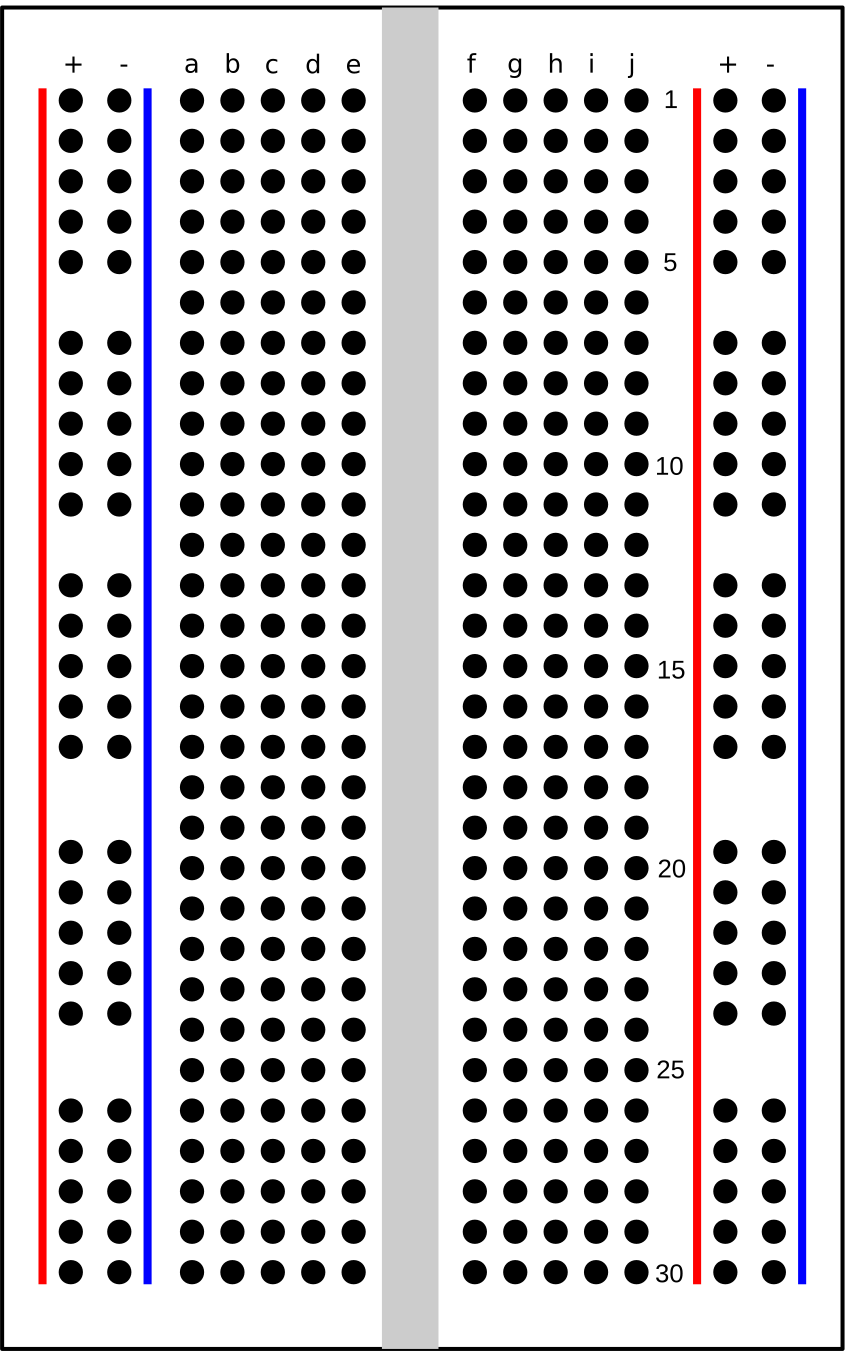

In [8]:
import cv2
import numpy as np
import glob
import os
import base64
import json
from ultralytics import YOLO
from google.colab import files
from IPython.display import HTML, display

# --- 1. 배경 이미지 (깔끔한 빵판) 로드 ---
CLEAN_BREADBOARD_IMG = '/content/clean_breadboard.png'
cb_canvas = cv2.imread(CLEAN_BREADBOARD_IMG)

if cb_canvas is None:
    print("🚨 [오류] 'clean_breadboard.png' 파일을 찾을 수 없습니다. 왼쪽 폴더에 업로드 해주세요.")
else:
    CB_HEIGHT, CB_WIDTH, _ = cb_canvas.shape

    # 여백 보정 (기본적인 시작점)
    roi_x1, roi_x2 = int(CB_WIDTH * 0.10), int(CB_WIDTH * 0.90)
    roi_y1, roi_y2 = int(CB_HEIGHT * 0.15), int(CB_HEIGHT * 0.85)
    roi_w, roi_h = roi_x2 - roi_x1, roi_y2 - roi_y1

    # --- 2. 빵판 구멍 자동 인식 (OpenCV) ---
    gray = cv2.cvtColor(cb_canvas, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    holes_data = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0: continue
        circularity = 4 * np.pi * (area / (perimeter * perimeter))
        if 0.7 < circularity <= 1.2 and 10 < area < 2000:
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                holes_data.append({"x": cx, "y": cy})

    # --- 3. 모델 로드 ---
    weight_paths = glob.glob('/content/runs/detect/*/weights/best.pt')
    if not weight_paths:
        print("🚨 [오류] 학습된 모델을 찾을 수 없습니다.")
    else:
        latest_weight_path = max(weight_paths, key=os.path.getctime)
        trained_model = YOLO(latest_weight_path)

        # --- 4. 사진 업로드 및 추론 ---
        print("\n👇 [파일 선택] 버튼을 눌러 실제 빵판 사진을 업로드해주세요!")
        uploaded = files.upload()

        if uploaded:
            real_image_path = list(uploaded.keys())[0]
            real_img = cv2.imread(real_image_path)
            real_h, real_w, _ = real_img.shape

            results = trained_model(real_image_path)
            result = results[0]

            components_data = []

            for i, box in enumerate(result.boxes):
                class_name = trained_model.names[int(box.cls[0].item())].lower()
                xmin, ymin, xmax, ymax = map(int, box.xyxy[0].tolist())

                # 비율 계산
                rel_xmin, rel_ymin = xmin / real_w, ymin / real_h
                rel_xmax, rel_ymax = xmax / real_w, ymax / real_h

                cb_xmin = roi_x1 + int(rel_xmin * roi_w)
                cb_ymin = roi_y1 + int(rel_ymin * roi_h)
                cb_w = int((rel_xmax - rel_xmin) * roi_w)
                cb_h = int((rel_ymax - rel_ymin) * roi_h)

                components_data.append({
                    "id": i,
                    "name": f"{class_name}_{i+1}",
                    "type": class_name,
                    "x": cb_xmin,
                    "y": cb_ymin,
                    "w": cb_w,
                    "h": cb_h
                })

            # --- 5. 배경 이미지를 Base64로 인코딩 ---
            with open(CLEAN_BREADBOARD_IMG, "rb") as image_file:
                encoded_string = base64.b64encode(image_file.read()).decode()
            bg_base64 = f"data:image/png;base64,{encoded_string}"

            json_components = json.dumps(components_data)
            json_holes = json.dumps(holes_data)

            # --- 6. HTML+JS: 드래그 앤 드롭 & 크기 조절 시뮬레이터 ---
            html_code = f"""
            <div style="text-align: center; font-family: sans-serif;">
                <h3 style="color: #333;">🖱️ ↔️ 부품을 잡고 이동하거나, 우측 하단의 <span style="color:red;">빨간 네모</span>를 잡아 크기를 조절하세요!</h3>
                <div style="display: inline-block; position: relative;">
                    <canvas id="breadboardCanvas" width="{CB_WIDTH}" height="{CB_HEIGHT}"
                            style="border: 2px solid #555; max-width: 100%; height: auto; box-shadow: 2px 2px 10px rgba(0,0,0,0.3);"></canvas>
                </div>
                <br>
                <button onclick="printFinalPositions()" style="padding: 12px 24px; font-size: 16px; font-weight: bold; margin-top: 15px; cursor: pointer; background-color: #4CAF50; color: white; border: none; border-radius: 5px;">✅ 수정 완료 (최종 핀 좌표 출력)</button>
                <pre id="outputConsole" style="text-align: left; background: #222; color: #0f0; padding: 15px; margin-top: 15px; max-height: 250px; overflow-y: auto; border-radius: 5px; font-size: 14px; width: 80%; margin-left: auto; margin-right: auto;"></pre>
            </div>

            <script>
                const canvas = document.getElementById('breadboardCanvas');
                const ctx = canvas.getContext('2d');
                const outputConsole = document.getElementById('outputConsole');

                let items = {json_components};
                let holes = {json_holes};
                let bgImg = new Image();
                bgImg.src = "{bg_base64}";

                let isDragging = false;
                let isResizing = false;
                let dragTarget = null;
                let offsetX, offsetY;
                const HANDLE_SIZE = 12; // 크기 조절 핸들 크기

                bgImg.onload = () => draw();

                // 가장 가까운 구멍 찾기 (자석 기능)
                function getNearestHole(px, py) {{
                    let minDist = Infinity;
                    let nearest = null;
                    holes.forEach(h => {{
                        let d = Math.hypot(h.x - px, h.y - py);
                        if (d < minDist) {{
                            minDist = d;
                            nearest = h;
                        }}
                    }});
                    return nearest;
                }}

                function draw() {{
                    ctx.clearRect(0, 0, canvas.width, canvas.height);
                    ctx.drawImage(bgImg, 0, 0, canvas.width, canvas.height);

                    items.forEach(item => {{
                        // 몸통 그리기 (마젠타색, 가시성 개선)
                        ctx.fillStyle = "rgba(255, 0, 255, 0.2)";
                        ctx.strokeStyle = "rgba(255, 0, 255, 1)";
                        ctx.lineWidth = 2;
                        ctx.fillRect(item.x, item.y, item.w, item.h);
                        ctx.strokeRect(item.x, item.y, item.w, item.h);

                        // 이름 텍스트
                        ctx.fillStyle = "#8B008B"; // 진한 보라색
                        ctx.font = "bold 16px Arial";
                        ctx.fillText(item.name, item.x, item.y - 8);

                        // 🌟 크기 조절 핸들(빨간색 네모) 우측 하단에 그리기
                        ctx.fillStyle = "red";
                        ctx.fillRect(item.x + item.w - HANDLE_SIZE, item.y + item.h - HANDLE_SIZE, HANDLE_SIZE, HANDLE_SIZE);

                        // 핀(다리) 그리기
                        drawPins(item);
                    }});
                }}

                function drawPins(item) {{
                    let pins = [];
                    // 비율과 크기에 맞춰 핀 위치 동적 계산
                    if (['fet', 'mosfet'].includes(item.type)) {{
                        let mid_x = item.x + (item.w / 2);
                        pins.push({{x: mid_x, y: item.y, color: "blue"}}); // S
                        pins.push({{x: mid_x, y: item.y + (item.h / 2), color: "green"}}); // D
                        pins.push({{x: mid_x, y: item.y + item.h, color: "red"}}); // G
                    }} else if (['res', 'led', 'cap', 'jump'].includes(item.type)) {{
                        if (item.w > item.h) {{
                            let mid_y = item.y + (item.h / 2);
                            pins.push({{x: item.x, y: mid_y, color: "red"}});
                            pins.push({{x: item.x + item.w, y: mid_y, color: "red"}});
                        }} else {{
                            let mid_x = item.x + (item.w / 2);
                            pins.push({{x: mid_x, y: item.y, color: "red"}});
                            pins.push({{x: mid_x, y: item.y + item.h, color: "red"}});
                        }}
                    }} else {{
                        pins.push({{x: item.x, y: item.y + item.h, color: "red"}});
                        pins.push({{x: item.x + item.w, y: item.y + item.h, color: "red"}});
                    }}

                    // 화면에 핀 찍기 및 가장 가까운 구멍과 선 연결 (스냅 시각화)
                    pins.forEach(pin => {{
                        let nearest = getNearestHole(pin.x, pin.y);

                        // 다리에서 진짜 꽂히는 구멍까지 점선 그리기
                        if (nearest) {{
                            ctx.beginPath();
                            ctx.moveTo(pin.x, pin.y);
                            ctx.lineTo(nearest.x, nearest.y);
                            ctx.strokeStyle = "rgba(0,0,0,0.5)";
                            ctx.setLineDash([5, 5]);
                            ctx.stroke();
                            ctx.setLineDash([]);

                            // 구멍에 자석처럼 붙은 위치(정답 좌표)에 검은 테두리 강조
                            ctx.beginPath();
                            ctx.arc(nearest.x, nearest.y, 7, 0, 2 * Math.PI, false);
                            ctx.strokeStyle = "black";
                            ctx.lineWidth = 2;
                            ctx.stroke();
                        }}

                        // 몸통 끝의 핀 위치 그리기
                        ctx.beginPath();
                        ctx.arc(pin.x, pin.y, 6, 0, 2 * Math.PI, false);
                        ctx.fillStyle = pin.color;
                        ctx.fill();
                        ctx.strokeStyle = 'white';
                        ctx.stroke();
                    }});
                }}

                function getMousePos(evt) {{
                    const rect = canvas.getBoundingClientRect();
                    const scaleX = canvas.width / rect.width;
                    const scaleY = canvas.height / rect.height;
                    return {{
                        x: (evt.clientX - rect.left) * scaleX,
                        y: (evt.clientY - rect.top) * scaleY
                    }};
                }}

                canvas.addEventListener('mousedown', function(e) {{
                    const pos = getMousePos(e);
                    // 레이어가 겹쳤을 때를 위해 역순 탐색
                    for (let i = items.length - 1; i >= 0; i--) {{
                        let item = items[i];

                        // 1. 크기 조절 핸들(우측 하단)을 클릭했는지 먼저 확인
                        if (pos.x >= item.x + item.w - HANDLE_SIZE && pos.x <= item.x + item.w &&
                            pos.y >= item.y + item.h - HANDLE_SIZE && pos.y <= item.y + item.h) {{
                            isResizing = true;
                            dragTarget = item;
                            canvas.style.cursor = 'nwse-resize';
                            return;
                        }}

                        // 2. 몸통을 클릭했는지 확인 (이동)
                        if (pos.x >= item.x && pos.x <= item.x + item.w &&
                            pos.y >= item.y && pos.y <= item.y + item.h) {{
                            isDragging = true;
                            dragTarget = item;
                            offsetX = pos.x - item.x;
                            offsetY = pos.y - item.y;
                            canvas.style.cursor = 'grabbing';
                            return;
                        }}
                    }}
                }});

                canvas.addEventListener('mousemove', function(e) {{
                    const pos = getMousePos(e);

                    // 마우스 커서 모양 변경 로직 (핸들 위에 올라가면 화살표로)
                    let onHandle = false;
                    for (let i = items.length - 1; i >= 0; i--) {{
                        let item = items[i];
                        if (pos.x >= item.x + item.w - HANDLE_SIZE && pos.x <= item.x + item.w &&
                            pos.y >= item.y + item.h - HANDLE_SIZE && pos.y <= item.y + item.h) {{
                            onHandle = true;
                            break;
                        }}
                    }}
                    if (!isDragging && !isResizing) {{
                        canvas.style.cursor = onHandle ? 'nwse-resize' : 'default';
                    }}

                    // 드래그 또는 리사이즈 처리
                    if (isDragging && dragTarget) {{
                        dragTarget.x = pos.x - offsetX;
                        dragTarget.y = pos.y - offsetY;
                        draw();
                    }} else if (isResizing && dragTarget) {{
                        // 크기 조절 시 최소 크기 제한(20px)
                        let newW = pos.x - dragTarget.x;
                        let newH = pos.y - dragTarget.y;
                        if (newW > 20) dragTarget.w = newW;
                        if (newH > 20) dragTarget.h = newH;
                        draw();
                    }}
                }});

                canvas.addEventListener('mouseup', function(e) {{
                    isDragging = false;
                    isResizing = false;
                    dragTarget = null;
                    canvas.style.cursor = 'default';
                    draw(); // 마우스를 뗄 때 한 번 더 갱신하여 점선 렌더링
                }});

                canvas.addEventListener('mouseleave', function(e) {{
                    isDragging = false;
                    isResizing = false;
                    dragTarget = null;
                    canvas.style.cursor = 'default';
                    draw();
                }});

                function printFinalPositions() {{
                    let out = "🌟 [최종 수정된 핀(Pin) 빵판 구멍 좌표]\\n\\n";
                    items.forEach(item => {{
                        out += `[${{item.name}}]\\n`;

                        let p1, p2, p3;
                        if (['fet', 'mosfet'].includes(item.type)) {{
                            p1 = getNearestHole(item.x + item.w/2, item.y);
                            p2 = getNearestHole(item.x + item.w/2, item.y + item.h/2);
                            p3 = getNearestHole(item.x + item.w/2, item.y + item.h);
                            out += ` - Source (파랑): X(${{p1.x}}), Y(${{p1.y}})\\n`;
                            out += ` - Drain (초록): X(${{p2.x}}), Y(${{p2.y}})\\n`;
                            out += ` - Gate (빨강): X(${{p3.x}}), Y(${{p3.y}})\\n\\n`;
                        }} else {{
                            if (item.w > item.h) {{
                                p1 = getNearestHole(item.x, item.y + item.h/2);
                                p2 = getNearestHole(item.x + item.w, item.y + item.h/2);
                            }} else {{
                                p1 = getNearestHole(item.x + item.w/2, item.y);
                                p2 = getNearestHole(item.x + item.w/2, item.y + item.h);
                            }}
                            out += ` - Pin1: X(${{p1.x}}), Y(${{p1.y}})\\n`;
                            out += ` - Pin2: X(${{p2.x}}), Y(${{p2.y}})\\n\\n`;
                        }}
                    }});
                    outputConsole.innerText = out;
                }}
            </script>
            """

            display(HTML(html_code))

🎯 인식된 구멍: 433개 / 생성된 회로 라인(Net): 68개 (성공!)

👇 [파일 선택] 버튼을 눌러 실제 빵판 사진을 업로드해주세요!


Saving 1.jpg to 1 (1).jpg

image 1/1 /content/1 (1).jpg: 640x384 1 fet, 3 ress, 3 jumps, 7.3ms
Speed: 2.5ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 384)



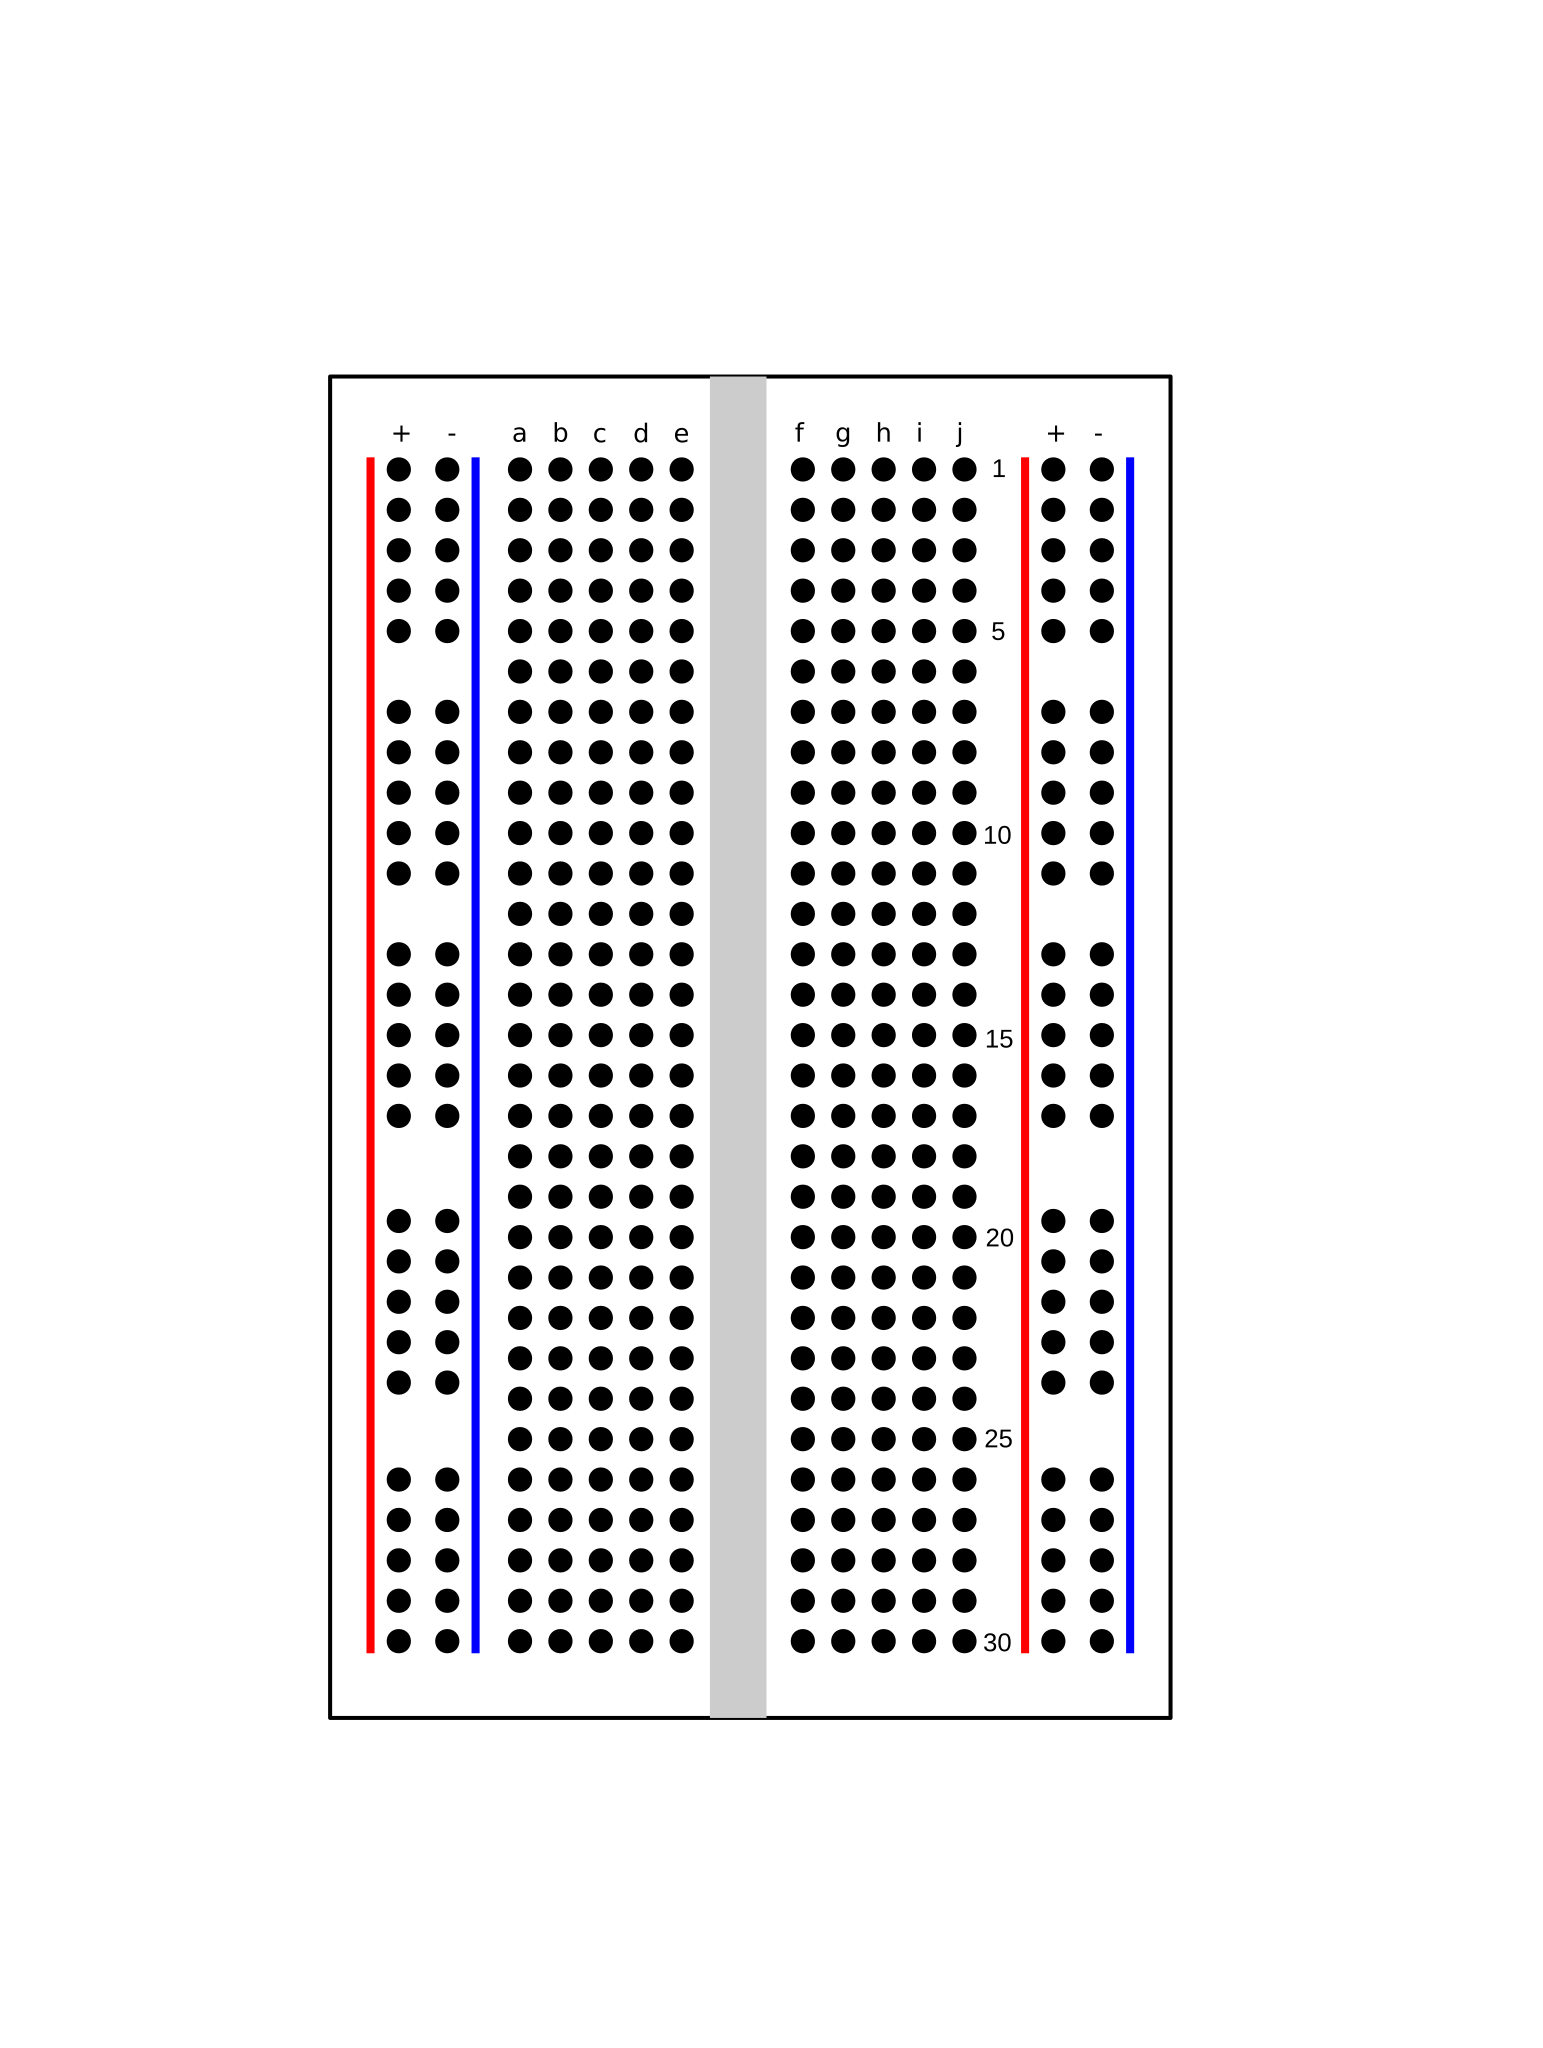

In [23]:
import cv2

import numpy as np

import glob

import os

import base64

import json

from ultralytics import YOLO

from google.colab import files

from IPython.display import HTML, display



# --- 1. 배경 이미지 로드 ---

CLEAN_BREADBOARD_IMG = '/content/clean_breadboard.png'

cb_canvas = cv2.imread(CLEAN_BREADBOARD_IMG)



if cb_canvas is None:

    print("🚨 [오류] 'clean_breadboard.png' 파일을 찾을 수 없습니다. 왼쪽 폴더에 업로드 해주세요.")

else:

    CB_HEIGHT, CB_WIDTH, _ = cb_canvas.shape

    roi_x1, roi_x2 = int(CB_WIDTH * 0.10), int(CB_WIDTH * 0.90)

    roi_y1, roi_y2 = int(CB_HEIGHT * 0.15), int(CB_HEIGHT * 0.85)

    roi_w, roi_h = roi_x2 - roi_x1, roi_y2 - roi_y1



    # --- 2. [수정됨] 훨씬 관대한 빵판 구멍 자동 인식 ---

    gray = cv2.cvtColor(cb_canvas, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV) # 어두운 구멍을 더 잘 찾도록 수정

    contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)



    holes_data = []

    for cnt in contours:

        x, y, w, h = cv2.boundingRect(cnt)

        area = w * h

        # 모양이 살짝 찌그러져도 구멍으로 인식하도록 관대한 조건 적용

        if 5 < area < 2500 and 0.4 < w/h < 2.5:

            holes_data.append({"x": x + w//2, "y": y + h//2, "net_id": None})



    if not holes_data:

        print("🚨 [오류] 그림 파일에서 구멍을 전혀 찾지 못했습니다!")

    else:

        # --- 3. 🌟 [완전 개편] 4구역(Zone) 기반 강력한 Net 그룹화 알고리즘 ---

        x_coords = [h['x'] for h in holes_data]

        min_x, max_x = min(x_coords), max(x_coords)

        span_x = max_x - min_x



        # 빵판의 4개 구역을 비율로 자동 분할

        Z1_END = min_x + span_x * 0.18    # 왼쪽 전원부 (+, -)

        Z2_END = min_x + span_x * 0.48    # 왼쪽 메인부 (a~e)

        Z3_START = min_x + span_x * 0.52  # 오른쪽 메인부 (f~j)

        Z4_START = min_x + span_x * 0.82  # 오른쪽 전원부 (+, -)



        # 오차 범위를 매우 넉넉하게 설정 (전체 폭의 1.5%)

        TOL = span_x * 0.015



        net_map = {i: i for i in range(len(holes_data))}

        def find(i):

            if net_map[i] == i: return i

            net_map[i] = find(net_map[i])

            return net_map[i]

        def union(i, j):

            root_i, root_j = find(i), find(j)

            if root_i != root_j: net_map[root_i] = root_j



        # 구역별 맞춤형 연결 로직

        for i in range(len(holes_data)):

            for j in range(i+1, len(holes_data)):

                h1, h2 = holes_data[i], holes_data[j]

                dx, dy = abs(h1['x'] - h2['x']), abs(h1['y'] - h2['y'])



                # 1번 구멍의 구역 찾기

                if h1['x'] < Z1_END: z1 = 1

                elif h1['x'] < Z2_END: z1 = 2

                elif h1['x'] > Z4_START: z1 = 4

                elif h1['x'] >= Z3_START: z1 = 3

                else: z1 = 0



                # 2번 구멍의 구역 찾기

                if h2['x'] < Z1_END: z2 = 1

                elif h2['x'] < Z2_END: z2 = 2

                elif h2['x'] > Z4_START: z2 = 4

                elif h2['x'] >= Z3_START: z2 = 3

                else: z2 = 0



                # 같은 구역 안에 있는 구멍들만 묶습니다!

                if z1 == z2 and z1 != 0:

                    if z1 == 2 or z1 == 3: # [메인 구역] 가로로 인접하면 묶음 (Y가 같아야 함)

                        if dy < TOL: union(i, j)

                    elif z1 == 1 or z1 == 4: # [전원 구역] 세로로 인접하면 묶음 (X가 같아야 함)

                        if dx < TOL: union(i, j)



        # Net 이름 부여

        net_dict = {}

        net_counter = 1

        for i in range(len(holes_data)):

            root = find(i)

            if root not in net_dict:

                net_dict[root] = f"NET_{net_counter:03d}"

                net_counter += 1

            holes_data[i]['net_id'] = net_dict[root]



        print(f"🎯 인식된 구멍: {len(holes_data)}개 / 생성된 회로 라인(Net): {net_counter-1}개 (성공!)")



        # --- 4. 모델 추론 ---

        weight_paths = glob.glob('/content/runs/detect/*/weights/best.pt')

        if not weight_paths:

            print("🚨 [오류] 학습된 모델을 찾을 수 없습니다.")

        else:

            trained_model = YOLO(max(weight_paths, key=os.path.getctime))



            print("\n👇 [파일 선택] 버튼을 눌러 실제 빵판 사진을 업로드해주세요!")

            uploaded = files.upload()



            if uploaded:

                real_image_path = list(uploaded.keys())[0]

                real_img = cv2.imread(real_image_path)

                real_h, real_w, _ = real_img.shape



                results = trained_model(real_image_path)

                result = results[0]



                components_data = []

                for i, box in enumerate(result.boxes):

                    class_name = trained_model.names[int(box.cls[0].item())].lower()

                    xmin, ymin, xmax, ymax = map(int, box.xyxy[0].tolist())



                    rel_xmin, rel_ymin = xmin / real_w, ymin / real_h

                    rel_xmax, rel_ymax = xmax / real_w, ymax / real_h



                    cb_xmin = roi_x1 + int(rel_xmin * roi_w)

                    cb_ymin = roi_y1 + int(rel_ymin * roi_h)

                    cb_w = int((rel_xmax - rel_xmin) * roi_w)

                    cb_h = int((rel_ymax - rel_ymin) * roi_h)



                    components_data.append({

                        "id": i, "name": f"{class_name}_{i+1}", "type": class_name,

                        "x": cb_xmin, "y": cb_ymin, "w": cb_w, "h": cb_h

                    })



                with open(CLEAN_BREADBOARD_IMG, "rb") as image_file:

                    encoded_string = base64.b64encode(image_file.read()).decode()

                bg_base64 = f"data:image/png;base64,{encoded_string}"



                json_components = json.dumps(components_data)

                json_holes = json.dumps(holes_data)



                # --- 5. HTML+JS 시뮬레이터 (선 그리기 로직 개선) ---

                html_code = f"""

                <div style="text-align: center; font-family: sans-serif;">

                    <h3 style="color: #333;">💡 이제 <span style="color: #00AA00; font-weight:bold;">초록색 연결망</span>이 완벽하게 보일 겁니다!</h3>

                    <p>같은 초록색 선 위에 부품들의 다리를 꽂고 추출 버튼을 눌러보세요.</p>

                    <div style="display: inline-block; position: relative;">

                        <canvas id="breadboardCanvas" width="{CB_WIDTH}" height="{CB_HEIGHT}"

                                style="border: 2px solid #555; max-width: 100%; height: auto; box-shadow: 2px 2px 10px rgba(0,0,0,0.3);"></canvas>

                    </div>

                    <br>

                    <button onclick="generateNetlist()" style="padding: 12px 24px; font-size: 16px; font-weight: bold; margin-top: 15px; cursor: pointer; background-color: #007BFF; color: white; border: none; border-radius: 5px;">✅ 넷리스트 추출하기</button>

                    <pre id="outputConsole" style="text-align: left; background: #222; color: #0f0; padding: 15px; margin-top: 15px; max-height: 400px; overflow-y: auto; border-radius: 5px; font-size: 15px; width: 80%; margin-left: auto; margin-right: auto; line-height: 1.6;"></pre>

                </div>



                <script>

                    const canvas = document.getElementById('breadboardCanvas');

                    const ctx = canvas.getContext('2d');

                    const outputConsole = document.getElementById('outputConsole');



                    let items = {json_components};

                    let holes = {json_holes};

                    let bgImg = new Image();

                    bgImg.src = "{bg_base64}";



                    let isDragging = false, isResizing = false;

                    let dragTarget = null, offsetX, offsetY;

                    const HANDLE_SIZE = 12;



                    let netGroups = {{}};

                    holes.forEach(h => {{

                        if (!netGroups[h.net_id]) netGroups[h.net_id] = [];

                        netGroups[h.net_id].push(h);

                    }});



                    bgImg.onload = () => draw();



                    function getNearestHole(px, py) {{

                        let minDist = Infinity, nearest = null;

                        holes.forEach(h => {{

                            let d = Math.hypot(h.x - px, h.y - py);

                            if (d < minDist) {{ minDist = d; nearest = h; }}

                        }});

                        return nearest;

                    }}



                    function draw() {{

                        ctx.clearRect(0, 0, canvas.width, canvas.height);

                        ctx.drawImage(bgImg, 0, 0, canvas.width, canvas.height);



                        // 🌟 빵판 내부 연결 실선 그리기 (그리기 로직 개선)

                        ctx.lineWidth = 6; // 선을 더 두껍게

                        ctx.strokeStyle = "rgba(0, 220, 50, 0.6)"; // 더 밝은 초록색

                        ctx.lineCap = "round";

                        ctx.lineJoin = "round";



                        for (let net in netGroups) {{

                            let hList = netGroups[net];

                            if (hList.length > 1) {{

                                // 세로줄인지 가로줄인지 파악하여 정렬 방향 결정

                                let dx = Math.abs(hList[0].x - hList[hList.length-1].x);

                                let dy = Math.abs(hList[0].y - hList[hList.length-1].y);



                                if (dx > dy) hList.sort((a, b) => a.x - b.x); // 가로 정렬

                                else hList.sort((a, b) => a.y - b.y); // 세로 정렬



                                ctx.beginPath();

                                ctx.moveTo(hList[0].x, hList[0].y);

                                for(let i=1; i<hList.length; i++) {{

                                    ctx.lineTo(hList[i].x, hList[i].y);

                                }}

                                ctx.stroke();

                            }}

                        }}



                        // 부품 그리기

                        items.forEach(item => {{

                            ctx.fillStyle = "rgba(255, 0, 255, 0.15)";

                            ctx.strokeStyle = "rgba(255, 0, 255, 1)";

                            ctx.lineWidth = 2;

                            ctx.fillRect(item.x, item.y, item.w, item.h);

                            ctx.strokeRect(item.x, item.y, item.w, item.h);



                            ctx.fillStyle = "#8B008B";

                            ctx.font = "bold 16px Arial";

                            ctx.fillText(item.name, item.x, item.y - 8);



                            ctx.fillStyle = "red";

                            ctx.fillRect(item.x + item.w - HANDLE_SIZE, item.y + item.h - HANDLE_SIZE, HANDLE_SIZE, HANDLE_SIZE);



                            drawPins(item);

                        }});

                    }}



                    function drawPins(item) {{

                        let pins = getPinCoords(item);

                        pins.forEach(pin => {{

                            let nearest = getNearestHole(pin.x, pin.y);

                            if (nearest) {{

                                ctx.beginPath();

                                ctx.moveTo(pin.x, pin.y); ctx.lineTo(nearest.x, nearest.y);

                                ctx.strokeStyle = "rgba(0,0,0,0.5)"; ctx.setLineDash([5, 5]); ctx.stroke(); ctx.setLineDash([]);



                                ctx.beginPath();

                                ctx.arc(nearest.x, nearest.y, 7, 0, 2 * Math.PI, false);

                                ctx.strokeStyle = "black"; ctx.lineWidth = 2; ctx.stroke();

                            }}



                            ctx.beginPath();

                            ctx.arc(pin.x, pin.y, 6, 0, 2 * Math.PI, false);

                            ctx.fillStyle = pin.color; ctx.fill(); ctx.strokeStyle = 'white'; ctx.stroke();

                        }});

                    }}



                    function getPinCoords(item) {{

                        let pins = [];

                        if (['fet', 'mosfet'].includes(item.type)) {{

                            let mid_x = item.x + (item.w / 2);

                            pins.push({{name: "Source", x: mid_x, y: item.y, color: "blue"}});

                            pins.push({{name: "Drain", x: mid_x, y: item.y + (item.h / 2), color: "green"}});

                            pins.push({{name: "Gate", x: mid_x, y: item.y + item.h, color: "red"}});

                        }} else if (['res', 'led', 'cap', 'jump'].includes(item.type)) {{

                            if (item.w > item.h) {{

                                let mid_y = item.y + (item.h / 2);

                                pins.push({{name: "Pin1", x: item.x, y: mid_y, color: "red"}});

                                pins.push({{name: "Pin2", x: item.x + item.w, y: mid_y, color: "red"}});

                            }} else {{

                                let mid_x = item.x + (item.w / 2);

                                pins.push({{name: "Pin1", x: mid_x, y: item.y, color: "red"}});

                                pins.push({{name: "Pin2", x: mid_x, y: item.y + item.h, color: "red"}});

                            }}

                        }} else {{

                            pins.push({{name: "Pin1", x: item.x, y: item.y + item.h, color: "red"}});

                            pins.push({{name: "Pin2", x: item.x + item.w, y: item.y + item.h, color: "red"}});

                        }}

                        return pins;

                    }}



                    function getMousePos(evt) {{

                        const rect = canvas.getBoundingClientRect();

                        const scaleX = canvas.width / rect.width; const scaleY = canvas.height / rect.height;

                        return {{ x: (evt.clientX - rect.left) * scaleX, y: (evt.clientY - rect.top) * scaleY }};

                    }}



                    canvas.addEventListener('mousedown', function(e) {{

                        const pos = getMousePos(e);

                        for (let i = items.length - 1; i >= 0; i--) {{

                            let item = items[i];

                            if (pos.x >= item.x + item.w - HANDLE_SIZE && pos.x <= item.x + item.w && pos.y >= item.y + item.h - HANDLE_SIZE && pos.y <= item.y + item.h) {{

                                isResizing = true; dragTarget = item; canvas.style.cursor = 'nwse-resize'; return;

                            }}

                            if (pos.x >= item.x && pos.x <= item.x + item.w && pos.y >= item.y && pos.y <= item.y + item.h) {{

                                isDragging = true; dragTarget = item; offsetX = pos.x - item.x; offsetY = pos.y - item.y; canvas.style.cursor = 'grabbing'; return;

                            }}

                        }}

                    }});



                    canvas.addEventListener('mousemove', function(e) {{

                        const pos = getMousePos(e);

                        if (isDragging && dragTarget) {{ dragTarget.x = pos.x - offsetX; dragTarget.y = pos.y - offsetY; draw(); }}

                        else if (isResizing && dragTarget) {{

                            let newW = pos.x - dragTarget.x; let newH = pos.y - dragTarget.y;

                            if (newW > 20) dragTarget.w = newW; if (newH > 20) dragTarget.h = newH;

                            draw();

                        }}

                    }});



                    canvas.addEventListener('mouseup', function(e) {{

                        isDragging = false; isResizing = false; dragTarget = null; canvas.style.cursor = 'default'; draw();

                    }});



                    canvas.addEventListener('mouseleave', function(e) {{

                        isDragging = false; isResizing = false; dragTarget = null; canvas.style.cursor = 'default'; draw();

                    }});



                    function generateNetlist() {{

                        let netlistMap = {{}};



                        items.forEach(item => {{

                            let pins = getPinCoords(item);

                            pins.forEach(pin => {{

                                let nearestHole = getNearestHole(pin.x, pin.y);

                                if (nearestHole && nearestHole.net_id) {{

                                    if (!netlistMap[nearestHole.net_id]) netlistMap[nearestHole.net_id] = [];

                                    netlistMap[nearestHole.net_id].push(`${{item.name}}(${{pin.name}})`);

                                }}

                            }});

                        }});



                        let out = "🔌 [최종 추출된 전기적 회로 넷리스트]\\n\\n";

                        let validConnections = false;



                        out += "🔗 [상호 연결된 노드]\\n";

                        for (let net in netlistMap) {{

                            if (netlistMap[net].length > 1) {{

                                out += `  - ${{net}} :  ${{netlistMap[net].join("  ↔  ")}}\\n`;

                                validConnections = true;

                            }}

                        }}



                        if (!validConnections) out += "  (아직 연결된 부품이 없습니다. 초록색 선을 공유하도록 다리를 놔주세요!)\\n";



                        out += "\\n📌 [단일 연결 (혼자 꽂힌 핀)]\\n";

                        for (let net in netlistMap) {{

                            if (netlistMap[net].length === 1) {{

                                out += `  - ${{net}} :  ${{netlistMap[net][0]}}\\n`;

                            }}

                        }}



                        outputConsole.innerText = out;

                    }}

                </script>

                """



                display(HTML(html_code))

🎯 인식된 구멍: 400개 / 생성된 회로 라인(Net): 64개 (성공!)

👇 [파일 선택] 버튼을 눌러 실제 빵판 사진을 업로드해주세요!


Saving report.jpg to report.jpg

image 1/1 /content/report.jpg: 640x480 2 caps, 1 fet, 2 leds, 5 ress, 47.3ms
Speed: 2.9ms preprocess, 47.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)



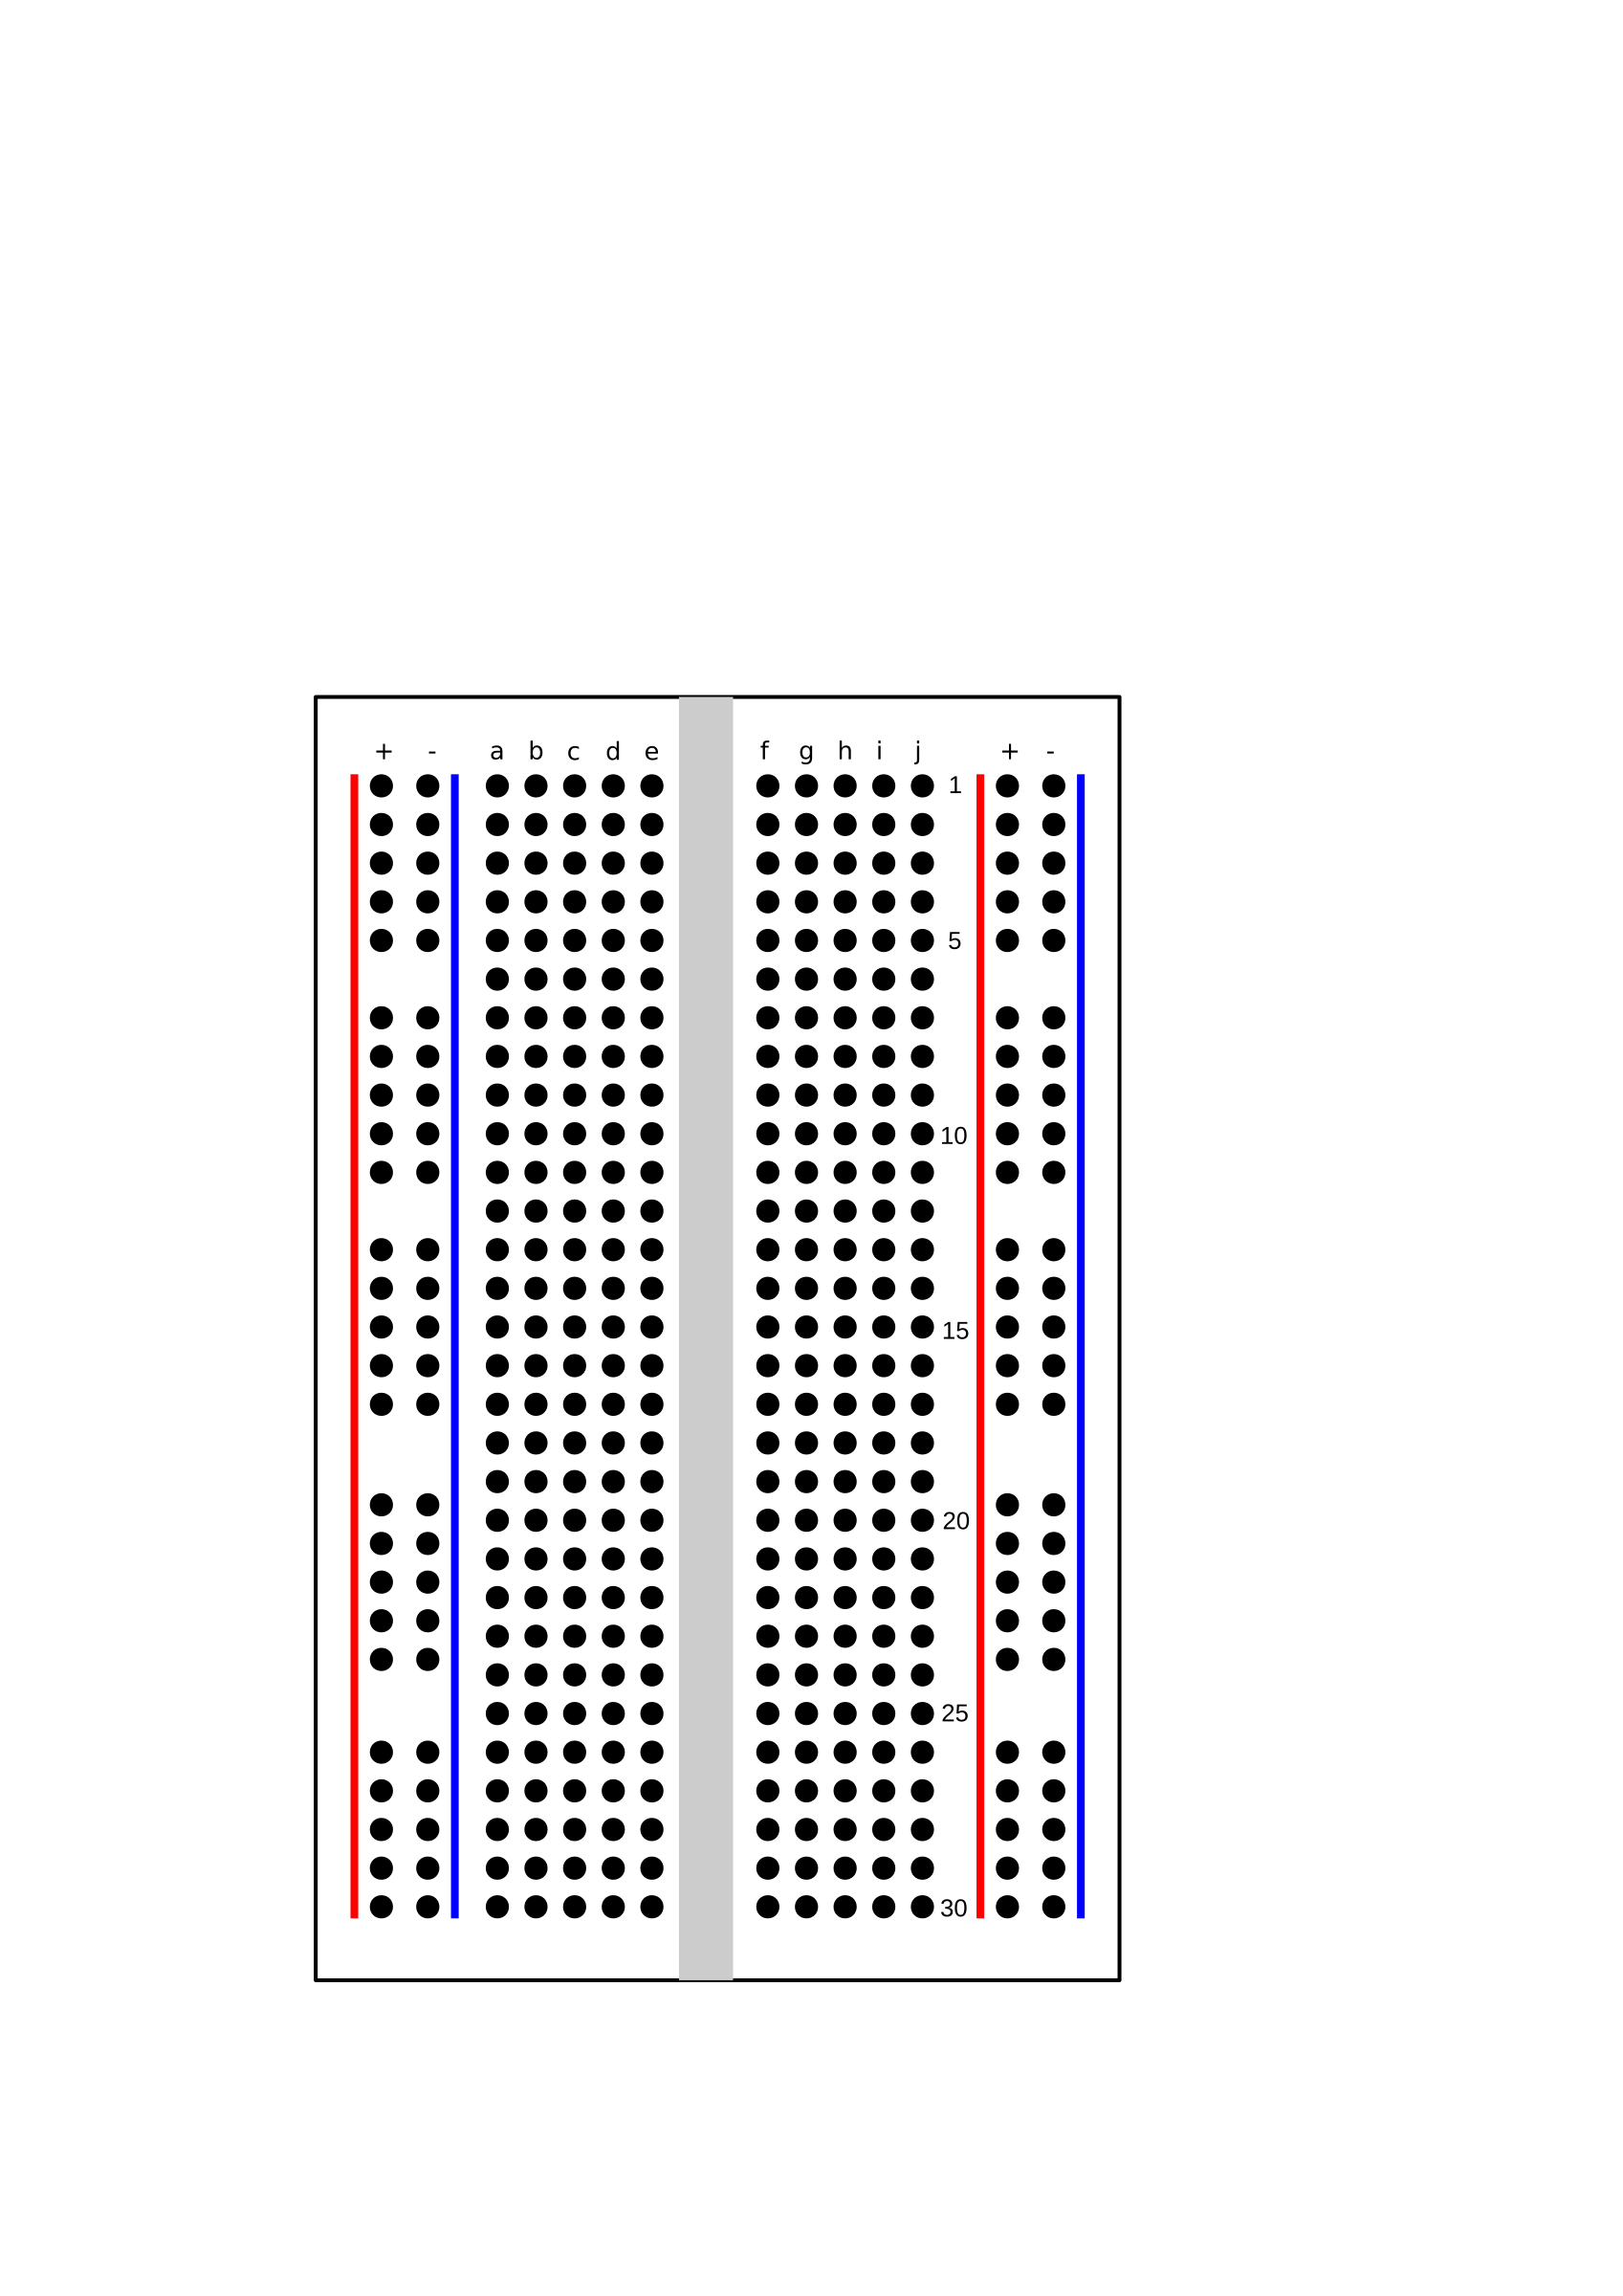

In [54]:
import cv2

import numpy as np

import glob

import os

import base64

import json

from ultralytics import YOLO

from google.colab import files

from IPython.display import HTML, display



# --- 1. 배경 이미지 로드 ---

CLEAN_BREADBOARD_IMG = '/content/clean_breadboard.png'

cb_canvas = cv2.imread(CLEAN_BREADBOARD_IMG)



if cb_canvas is None:

    print("🚨 [오류] 'clean_breadboard.png' 파일을 찾을 수 없습니다. 왼쪽 폴더에 업로드 해주세요.")

else:

    CB_HEIGHT, CB_WIDTH, _ = cb_canvas.shape

    roi_x1, roi_x2 = int(CB_WIDTH * 0.10), int(CB_WIDTH * 0.90)

    roi_y1, roi_y2 = int(CB_HEIGHT * 0.15), int(CB_HEIGHT * 0.85)

    roi_w, roi_h = roi_x2 - roi_x1, roi_y2 - roi_y1



# --- 2. 빵판 구멍 자동 인식 (글씨 및 기호 완벽 차단) ---
    gray = cv2.cvtColor(cb_canvas, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    temp_holes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        bbox_area = w * h
        contour_area = cv2.contourArea(cnt) # 실제 색칠된 픽셀의 면적

        if h == 0 or w == 0 or contour_area == 0: continue

        aspect_ratio = w / float(h)
        extent = contour_area / float(bbox_area) # 박스 대비 실제 면적 비율 (원은 약 0.78)

        # 1차 필터: 비율이 정사각형에 가깝고(0.75~1.3),
        # 내부가 꽉 차 있는(extent > 0.65) 형태만 통과 ('+' 기호 등은 여기서 탈락)
        if 20 < bbox_area < 1000 and 0.75 < aspect_ratio < 1.3 and extent > 0.65:
            temp_holes.append({"x": x + w//2, "y": y + h//2, "area": bbox_area})

    holes_data = []
    if not temp_holes:
        print("🚨 [오류] 그림 파일에서 구멍을 전혀 찾지 못했습니다!")
    else:
        # 2차 절대 필터: 찾아낸 구멍들의 '중간값(가장 흔한 크기)' 도출
        median_area = np.median([h['area'] for h in temp_holes])

        for h in temp_holes:
            # 빵판 구멍은 크기가 일정함! 중간값 기준 위아래 30% 오차를 벗어나면 글씨/먼지로 간주하고 탈락
            if median_area * 0.7 < h['area'] < median_area * 1.3:
                holes_data.append({"x": h['x'], "y": h['y'], "net_id": None})



        # 구역별 맞춤형 연결 로직 (이 아래는 기존 코드와 동일합니다)

        for i in range(len(holes_data)):

            for j in range(i+1, len(holes_data)):

                h1, h2 = holes_data[i], holes_data[j]

                dx, dy = abs(h1['x'] - h2['x']), abs(h1['y'] - h2['y'])



                # 1번 구멍의 구역 찾기

                if h1['x'] < Z1_END: z1 = 1

                elif h1['x'] < Z2_END: z1 = 2

                elif h1['x'] > Z4_START: z1 = 4

                elif h1['x'] >= Z3_START: z1 = 3

                else: z1 = 0



                # 2번 구멍의 구역 찾기

                if h2['x'] < Z1_END: z2 = 1

                elif h2['x'] < Z2_END: z2 = 2

                elif h2['x'] > Z4_START: z2 = 4

                elif h2['x'] >= Z3_START: z2 = 3

                else: z2 = 0



                # 같은 구역 안에 있는 구멍들만 묶습니다!

                if z1 == z2 and z1 != 0:

                    if z1 == 2 or z1 == 3: # [메인 구역] 가로로 인접하면 묶음 (Y가 같아야 함)

                        if dy < TOL: union(i, j)

                    elif z1 == 1 or z1 == 4: # [전원 구역] 세로로 인접하면 묶음 (X가 같아야 함)

                        if dx < TOL: union(i, j)



        # Net 이름 부여

        net_dict = {}

        net_counter = 1

        for i in range(len(holes_data)):

            root = find(i)

            if root not in net_dict:

                net_dict[root] = f"NET_{net_counter:03d}"

                net_counter += 1

            holes_data[i]['net_id'] = net_dict[root]



        print(f"🎯 인식된 구멍: {len(holes_data)}개 / 생성된 회로 라인(Net): {net_counter-1}개 (성공!)")



        # --- 4. 모델 추론 ---

        weight_paths = glob.glob('/content/runs/detect/*/weights/best.pt')

        if not weight_paths:

            print("🚨 [오류] 학습된 모델을 찾을 수 없습니다.")

        else:

            trained_model = YOLO(max(weight_paths, key=os.path.getctime))



            print("\n👇 [파일 선택] 버튼을 눌러 실제 빵판 사진을 업로드해주세요!")

            uploaded = files.upload()



            if uploaded:

                real_image_path = list(uploaded.keys())[0]

                real_img = cv2.imread(real_image_path)

                real_h, real_w, _ = real_img.shape



                results = trained_model(real_image_path)

                result = results[0]



                components_data = []

                for i, box in enumerate(result.boxes):

                    class_name = trained_model.names[int(box.cls[0].item())].lower()

                    xmin, ymin, xmax, ymax = map(int, box.xyxy[0].tolist())



                    rel_xmin, rel_ymin = xmin / real_w, ymin / real_h

                    rel_xmax, rel_ymax = xmax / real_w, ymax / real_h



                    cb_xmin = roi_x1 + int(rel_xmin * roi_w)

                    cb_ymin = roi_y1 + int(rel_ymin * roi_h)

                    cb_w = int((rel_xmax - rel_xmin) * roi_w)

                    cb_h = int((rel_ymax - rel_ymin) * roi_h)



                    components_data.append({

                        "id": i, "name": f"{class_name}_{i+1}", "type": class_name,

                        "x": cb_xmin, "y": cb_ymin, "w": cb_w, "h": cb_h

                    })



                with open(CLEAN_BREADBOARD_IMG, "rb") as image_file:

                    encoded_string = base64.b64encode(image_file.read()).decode()

                bg_base64 = f"data:image/png;base64,{encoded_string}"



                json_components = json.dumps(components_data)

                json_holes = json.dumps(holes_data)



                # --- 5. HTML+JS 시뮬레이터 (선 그리기 로직 개선) ---

                html_code = f"""

                <div style="text-align: center; font-family: sans-serif;">

                    <h3 style="color: #333;">💡 이제 <span style="color: #00AA00; font-weight:bold;">초록색 연결망</span>이 완벽하게 보일 겁니다!</h3>

                    <p>같은 초록색 선 위에 부품들의 다리를 꽂고 추출 버튼을 눌러보세요.</p>

                    <div style="display: inline-block; position: relative;">

                        <canvas id="breadboardCanvas" width="{CB_WIDTH}" height="{CB_HEIGHT}"

                                style="border: 2px solid #555; max-width: 100%; height: auto; box-shadow: 2px 2px 10px rgba(0,0,0,0.3);"></canvas>

                    </div>

                    <br>

                    <button onclick="generateNetlist()" style="padding: 12px 24px; font-size: 16px; font-weight: bold; margin-top: 15px; cursor: pointer; background-color: #007BFF; color: white; border: none; border-radius: 5px;">✅ 넷리스트 추출하기</button>

                    <pre id="outputConsole" style="text-align: left; background: #222; color: #0f0; padding: 15px; margin-top: 15px; max-height: 400px; overflow-y: auto; border-radius: 5px; font-size: 15px; width: 80%; margin-left: auto; margin-right: auto; line-height: 1.6;"></pre>

                </div>



                <script>

                    const canvas = document.getElementById('breadboardCanvas');

                    const ctx = canvas.getContext('2d');

                    const outputConsole = document.getElementById('outputConsole');



                    let items = {json_components};

                    let holes = {json_holes};

                    let bgImg = new Image();

                    bgImg.src = "{bg_base64}";



                    let isDragging = false, isResizing = false;

                    let dragTarget = null, offsetX, offsetY;

                    const HANDLE_SIZE = 12;



                    let netGroups = {{}};

                    holes.forEach(h => {{

                        if (!netGroups[h.net_id]) netGroups[h.net_id] = [];

                        netGroups[h.net_id].push(h);

                    }});



                    bgImg.onload = () => draw();



                    function getNearestHole(px, py) {{

                        let minDist = Infinity, nearest = null;

                        holes.forEach(h => {{

                            let d = Math.hypot(h.x - px, h.y - py);

                            if (d < minDist) {{ minDist = d; nearest = h; }}

                        }});

                        return nearest;

                    }}



                    function draw() {{

                        ctx.clearRect(0, 0, canvas.width, canvas.height);

                        ctx.drawImage(bgImg, 0, 0, canvas.width, canvas.height);



                        // 🌟 빵판 내부 연결 실선 그리기 (그리기 로직 개선)

                        ctx.lineWidth = 6; // 선을 더 두껍게

                        ctx.strokeStyle = "rgba(0, 220, 50, 0.6)"; // 더 밝은 초록색

                        ctx.lineCap = "round";

                        ctx.lineJoin = "round";



                        for (let net in netGroups) {{

                            let hList = netGroups[net];

                            if (hList.length > 1) {{

                                // 세로줄인지 가로줄인지 파악하여 정렬 방향 결정

                                let dx = Math.abs(hList[0].x - hList[hList.length-1].x);

                                let dy = Math.abs(hList[0].y - hList[hList.length-1].y);



                                if (dx > dy) hList.sort((a, b) => a.x - b.x); // 가로 정렬

                                else hList.sort((a, b) => a.y - b.y); // 세로 정렬



                                ctx.beginPath();

                                ctx.moveTo(hList[0].x, hList[0].y);

                                for(let i=1; i<hList.length; i++) {{

                                    ctx.lineTo(hList[i].x, hList[i].y);

                                }}

                                ctx.stroke();

                            }}

                        }}



                        // 부품 그리기

                        items.forEach(item => {{

                            ctx.fillStyle = "rgba(255, 0, 255, 0.15)";

                            ctx.strokeStyle = "rgba(255, 0, 255, 1)";

                            ctx.lineWidth = 2;

                            ctx.fillRect(item.x, item.y, item.w, item.h);

                            ctx.strokeRect(item.x, item.y, item.w, item.h);



                            ctx.fillStyle = "#8B008B";

                            ctx.font = "bold 16px Arial";

                            ctx.fillText(item.name, item.x, item.y - 8);



                            ctx.fillStyle = "red";

                            ctx.fillRect(item.x + item.w - HANDLE_SIZE, item.y + item.h - HANDLE_SIZE, HANDLE_SIZE, HANDLE_SIZE);



                            drawPins(item);

                        }});

                    }}



                    function drawPins(item) {{

                        let pins = getPinCoords(item);

                        pins.forEach(pin => {{

                            let nearest = getNearestHole(pin.x, pin.y);

                            if (nearest) {{

                                ctx.beginPath();

                                ctx.moveTo(pin.x, pin.y); ctx.lineTo(nearest.x, nearest.y);

                                ctx.strokeStyle = "rgba(0,0,0,0.5)"; ctx.setLineDash([5, 5]); ctx.stroke(); ctx.setLineDash([]);



                                ctx.beginPath();

                                ctx.arc(nearest.x, nearest.y, 7, 0, 2 * Math.PI, false);

                                ctx.strokeStyle = "black"; ctx.lineWidth = 2; ctx.stroke();

                            }}



                            ctx.beginPath();

                            ctx.arc(pin.x, pin.y, 6, 0, 2 * Math.PI, false);

                            ctx.fillStyle = pin.color; ctx.fill(); ctx.strokeStyle = 'white'; ctx.stroke();

                        }});

                    }}



                    function getPinCoords(item) {{

                        let pins = [];

                        if (['fet', 'mosfet'].includes(item.type)) {{

                            let mid_x = item.x + (item.w / 2);

                            pins.push({{name: "Source", x: mid_x, y: item.y, color: "blue"}});

                            pins.push({{name: "Drain", x: mid_x, y: item.y + (item.h / 2), color: "green"}});

                            pins.push({{name: "Gate", x: mid_x, y: item.y + item.h, color: "red"}});

                        }} else if (['res', 'led', 'cap', 'jump'].includes(item.type)) {{

                            if (item.w > item.h) {{

                                let mid_y = item.y + (item.h / 2);

                                pins.push({{name: "Pin1", x: item.x, y: mid_y, color: "red"}});

                                pins.push({{name: "Pin2", x: item.x + item.w, y: mid_y, color: "red"}});

                            }} else {{

                                let mid_x = item.x + (item.w / 2);

                                pins.push({{name: "Pin1", x: mid_x, y: item.y, color: "red"}});

                                pins.push({{name: "Pin2", x: mid_x, y: item.y + item.h, color: "red"}});

                            }}

                        }} else {{

                            pins.push({{name: "Pin1", x: item.x, y: item.y + item.h, color: "red"}});

                            pins.push({{name: "Pin2", x: item.x + item.w, y: item.y + item.h, color: "red"}});

                        }}

                        return pins;

                    }}



                    function getMousePos(evt) {{

                        const rect = canvas.getBoundingClientRect();

                        const scaleX = canvas.width / rect.width; const scaleY = canvas.height / rect.height;

                        return {{ x: (evt.clientX - rect.left) * scaleX, y: (evt.clientY - rect.top) * scaleY }};

                    }}



                    canvas.addEventListener('mousedown', function(e) {{

                        const pos = getMousePos(e);

                        for (let i = items.length - 1; i >= 0; i--) {{

                            let item = items[i];

                            if (pos.x >= item.x + item.w - HANDLE_SIZE && pos.x <= item.x + item.w && pos.y >= item.y + item.h - HANDLE_SIZE && pos.y <= item.y + item.h) {{

                                isResizing = true; dragTarget = item; canvas.style.cursor = 'nwse-resize'; return;

                            }}

                            if (pos.x >= item.x && pos.x <= item.x + item.w && pos.y >= item.y && pos.y <= item.y + item.h) {{

                                isDragging = true; dragTarget = item; offsetX = pos.x - item.x; offsetY = pos.y - item.y; canvas.style.cursor = 'grabbing'; return;

                            }}

                        }}

                    }});



                    canvas.addEventListener('mousemove', function(e) {{

                        const pos = getMousePos(e);

                        if (isDragging && dragTarget) {{ dragTarget.x = pos.x - offsetX; dragTarget.y = pos.y - offsetY; draw(); }}

                        else if (isResizing && dragTarget) {{

                            let newW = pos.x - dragTarget.x; let newH = pos.y - dragTarget.y;

                            if (newW > 20) dragTarget.w = newW; if (newH > 20) dragTarget.h = newH;

                            draw();

                        }}

                    }});



                    canvas.addEventListener('mouseup', function(e) {{

                        isDragging = false; isResizing = false; dragTarget = null; canvas.style.cursor = 'default'; draw();

                    }});



                    canvas.addEventListener('mouseleave', function(e) {{

                        isDragging = false; isResizing = false; dragTarget = null; canvas.style.cursor = 'default'; draw();

                    }});



                    function generateNetlist() {{

                        let netlistMap = {{}};



                        items.forEach(item => {{

                            let pins = getPinCoords(item);

                            pins.forEach(pin => {{

                                let nearestHole = getNearestHole(pin.x, pin.y);

                                if (nearestHole && nearestHole.net_id) {{

                                    if (!netlistMap[nearestHole.net_id]) netlistMap[nearestHole.net_id] = [];

                                    netlistMap[nearestHole.net_id].push(`${{item.name}}(${{pin.name}})`);

                                }}

                            }});

                        }});



                        let out = "🔌 [최종 추출된 전기적 회로 넷리스트]\\n\\n";

                        let validConnections = false;



                        out += "🔗 [상호 연결된 노드]\\n";

                        for (let net in netlistMap) {{

                            if (netlistMap[net].length > 1) {{

                                out += `  - ${{net}} :  ${{netlistMap[net].join("  ↔  ")}}\\n`;

                                validConnections = true;

                            }}

                        }}



                        if (!validConnections) out += "  (아직 연결된 부품이 없습니다. 초록색 선을 공유하도록 다리를 놔주세요!)\\n";



                        out += "\\n📌 [단일 연결 (혼자 꽂힌 핀)]\\n";

                        for (let net in netlistMap) {{

                            if (netlistMap[net].length === 1) {{

                                out += `  - ${{net}} :  ${{netlistMap[net][0]}}\\n`;

                            }}

                        }}



                        outputConsole.innerText = out;

                    }}

                </script>

                """



                display(HTML(html_code))

🎯 인식된 구멍: 400개 / 생성된 회로 라인(Net): 64개 (성공!)

👇 [파일 선택] 버튼을 눌러 실제 빵판 사진을 업로드해주세요!


Saving report.jpg to report (4).jpg

image 1/1 /content/report (4).jpg: 640x480 2 caps, 1 fet, 2 leds, 5 ress, 7.4ms
Speed: 3.2ms preprocess, 7.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)



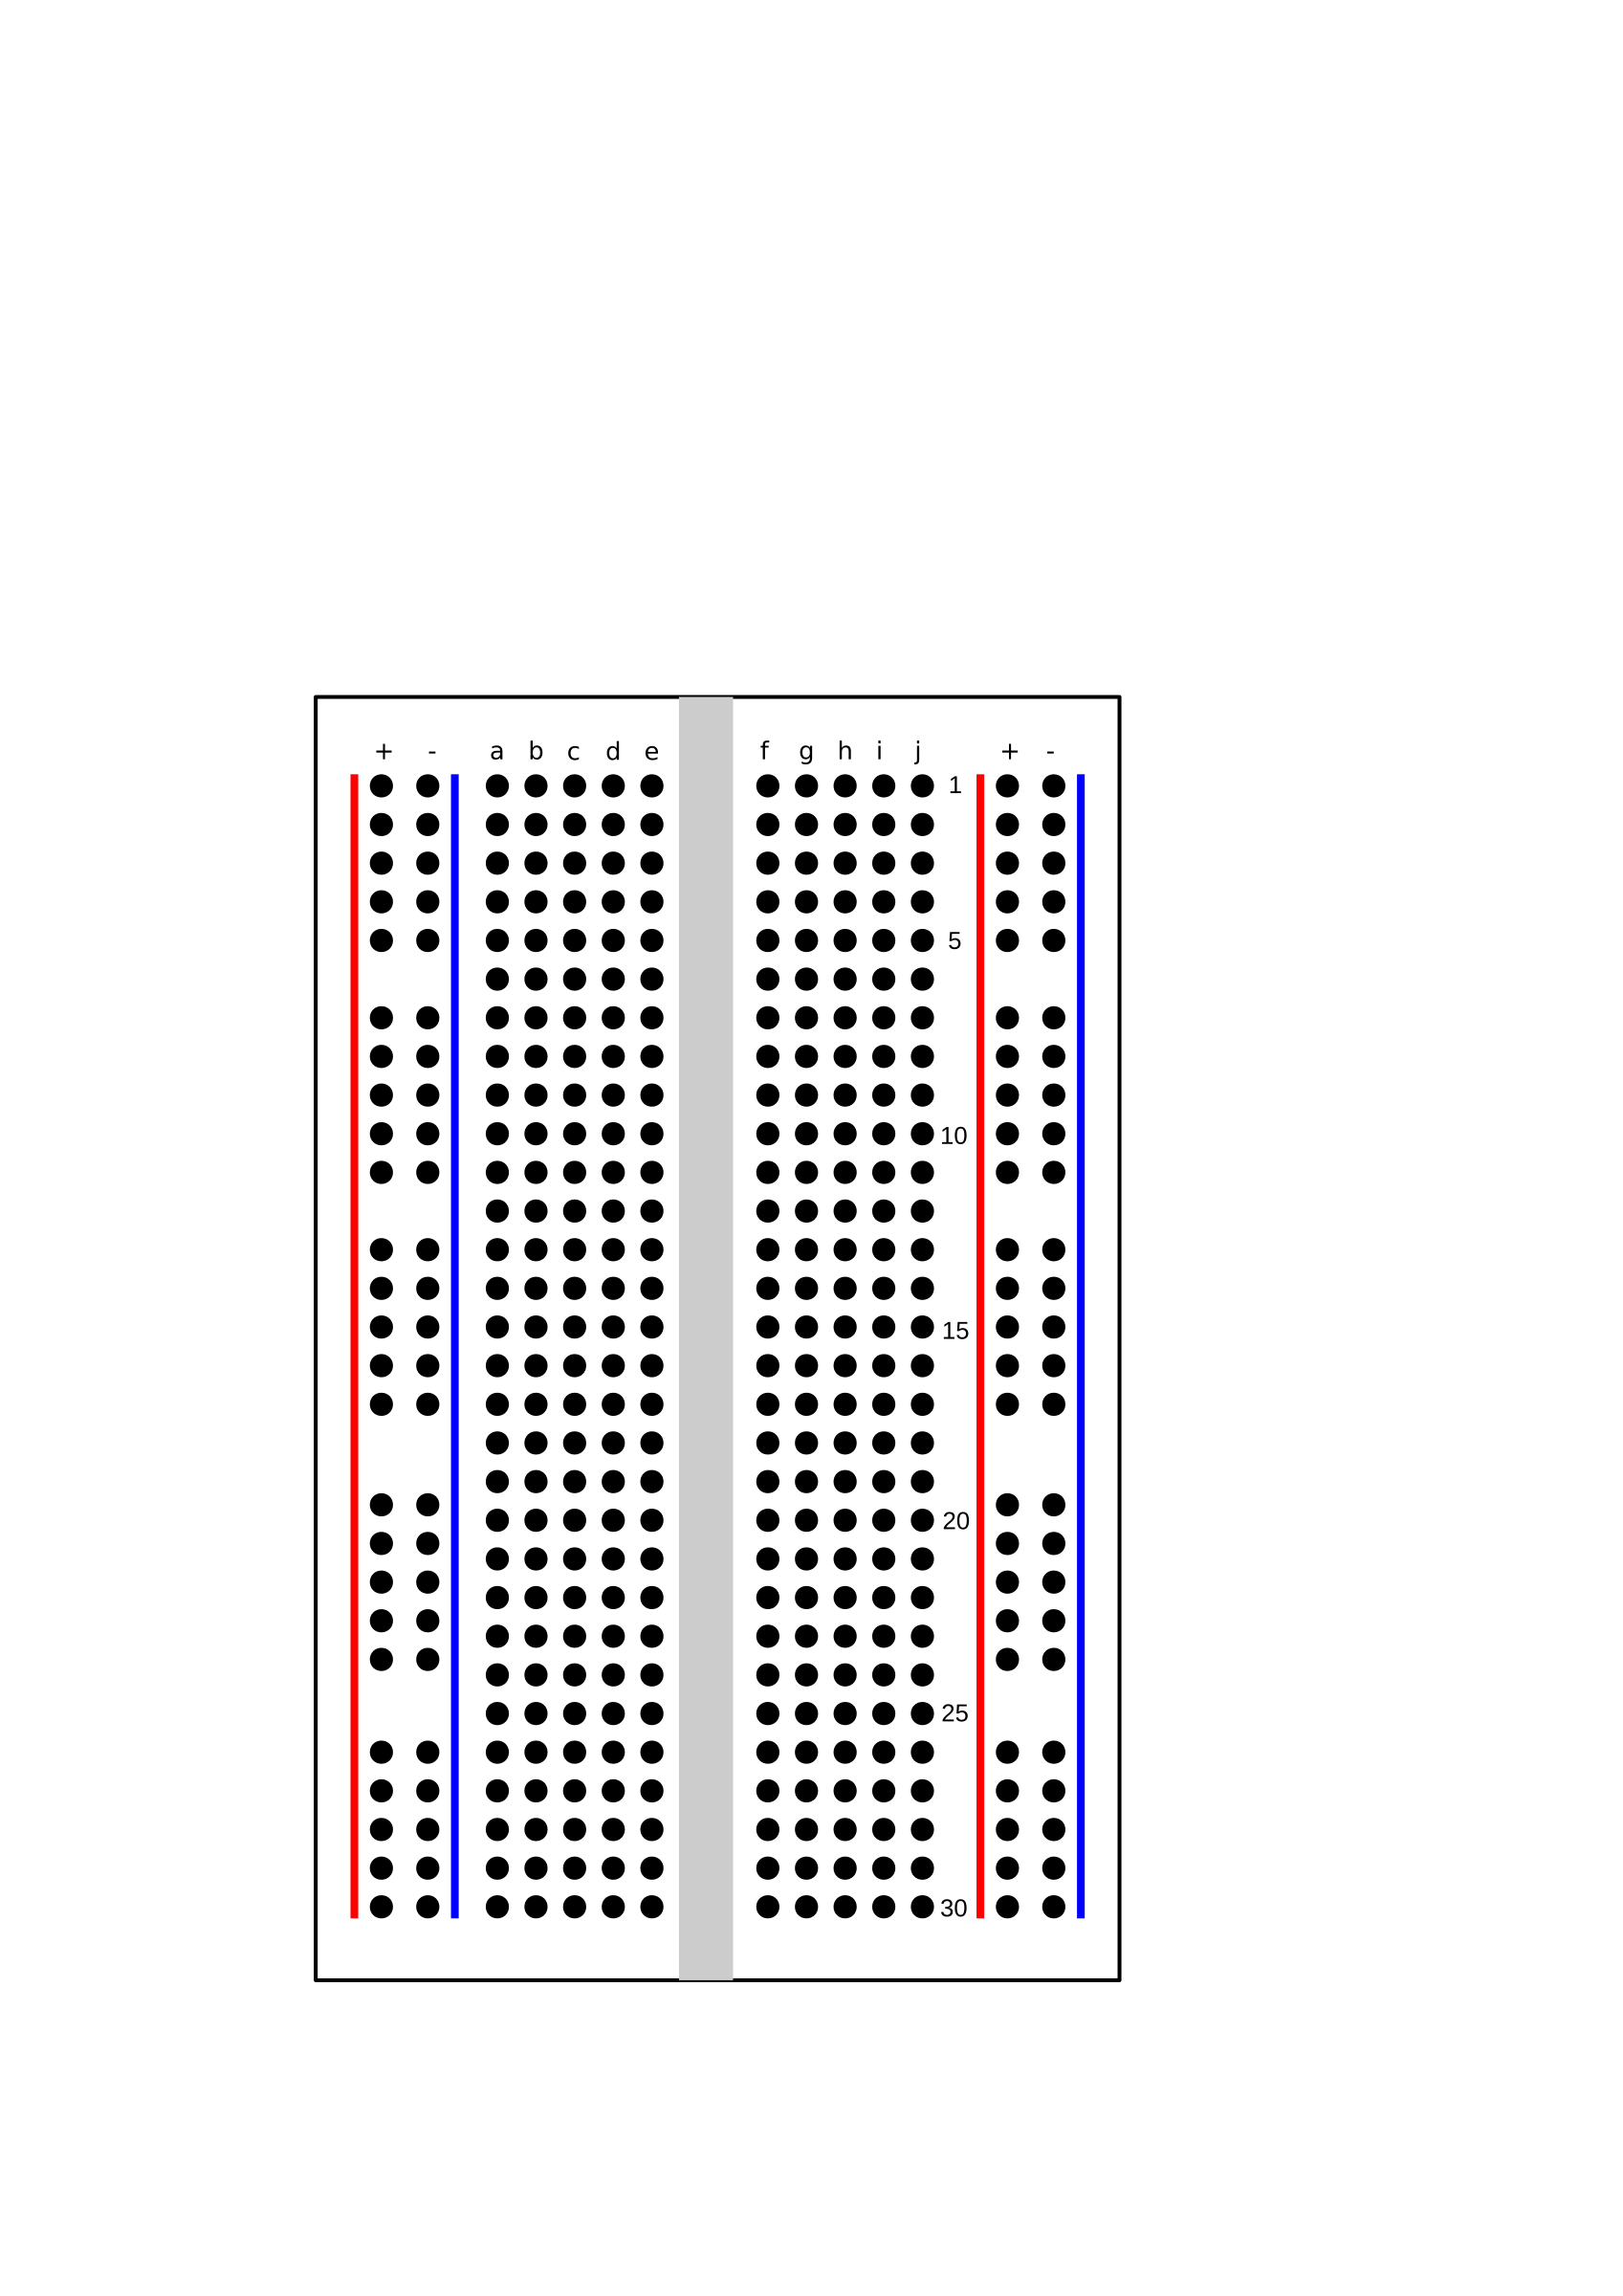

In [58]:
import cv2
import numpy as np
import glob
import os
import base64
import json
from ultralytics import YOLO
from google.colab import files
from IPython.display import HTML, display

# --- 1. 배경 이미지 로드 ---
CLEAN_BREADBOARD_IMG = '/content/clean_breadboard.png'
cb_canvas = cv2.imread(CLEAN_BREADBOARD_IMG)

if cb_canvas is None:
    print("🚨 [오류] 'clean_breadboard.png' 파일을 찾을 수 없습니다. 왼쪽 폴더에 업로드 해주세요.")
else:
    CB_HEIGHT, CB_WIDTH, _ = cb_canvas.shape
    roi_x1, roi_x2 = int(CB_WIDTH * 0.10), int(CB_WIDTH * 0.90)
    roi_y1, roi_y2 = int(CB_HEIGHT * 0.15), int(CB_HEIGHT * 0.85)
    roi_w, roi_h = roi_x2 - roi_x1, roi_y2 - roi_y1

    # --- 2. 🌟 빵판 구멍 자동 인식 (글씨 및 기호 완벽 차단) ---
    gray = cv2.cvtColor(cb_canvas, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    temp_holes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        bbox_area = w * h
        contour_area = cv2.contourArea(cnt)

        if h == 0 or w == 0 or contour_area == 0: continue

        aspect_ratio = w / float(h)
        extent = contour_area / float(bbox_area)

        # 1차 필터: 모양이 둥글고 꽉 찬 형태만 통과 ('+', 'a' 기호 등 1차 탈락)
        if 20 < bbox_area < 1000 and 0.75 < aspect_ratio < 1.3 and extent > 0.65:
            temp_holes.append({"x": x + w//2, "y": y + h//2, "area": bbox_area})

    holes_data = []
    if not temp_holes:
        print("🚨 [오류] 그림 파일에서 구멍을 전혀 찾지 못했습니다!")
    else:
        # 2차 절대 필터: 구멍들의 '중간값' 크기 도출 (크기가 다른 찌꺼기 완벽 차단)
        median_area = np.median([h['area'] for h in temp_holes])

        for h in temp_holes:
            if median_area * 0.7 < h['area'] < median_area * 1.3:
                holes_data.append({"x": h['x'], "y": h['y'], "net_id": None})

        # --- 3. 🌟 4구역(Zone) 기반 Net 그룹화 및 전원선 구분 ---
        x_coords = [h['x'] for h in holes_data]
        min_x, max_x = min(x_coords), max(x_coords)
        span_x = max_x - min_x

        # a열이 전원부로 끌려가지 않도록 구역 범위를 정밀하게 축소
        Z1_END = min_x + span_x * 0.12    # 왼쪽 전원부 (+, -)
        Z2_END = min_x + span_x * 0.48    # 왼쪽 메인부 (a~e)
        Z3_START = min_x + span_x * 0.52  # 오른쪽 메인부 (f~j)
        Z4_START = min_x + span_x * 0.88  # 오른쪽 전원부 (+, -)

        TOL = span_x * 0.015

        net_map = {i: i for i in range(len(holes_data))}
        def find(i):
            if net_map[i] == i: return i
            net_map[i] = find(net_map[i])
            return net_map[i]
        def union(i, j):
            root_i, root_j = find(i), find(j)
            if root_i != root_j: net_map[root_i] = root_j

        for i in range(len(holes_data)):
            for j in range(i+1, len(holes_data)):
                h1, h2 = holes_data[i], holes_data[j]
                dx, dy = abs(h1['x'] - h2['x']), abs(h1['y'] - h2['y'])

                if h1['x'] < Z1_END: z1 = 1
                elif h1['x'] < Z2_END: z1 = 2
                elif h1['x'] > Z4_START: z1 = 4
                elif h1['x'] >= Z3_START: z1 = 3
                else: z1 = 0

                if h2['x'] < Z1_END: z2 = 1
                elif h2['x'] < Z2_END: z2 = 2
                elif h2['x'] > Z4_START: z2 = 4
                elif h2['x'] >= Z3_START: z2 = 3
                else: z2 = 0

                if z1 == z2 and z1 != 0:
                    if z1 == 2 or z1 == 3: # 가로 묶음
                        if dy < TOL: union(i, j)
                    elif z1 == 1 or z1 == 4: # 세로 묶음
                        if dx < TOL: union(i, j)

        net_groups = {}
        for i in range(len(holes_data)):
            root = find(i)
            if root not in net_groups:
                net_groups[root] = []
            net_groups[root].append(holes_data[i])

        net_dict = {}
        net_counter = 1

        z1_roots, z4_roots = [], []

        for root, holes in net_groups.items():
            avg_x = sum(h['x'] for h in holes) / len(holes)
            if len(holes) < 3:
                net_dict[root] = f"IGNORE_{root}"
                continue

            if avg_x < Z1_END: z1_roots.append((root, avg_x))
            elif avg_x > Z4_START: z4_roots.append((root, avg_x))
            else:
                net_dict[root] = f"NET_{net_counter:03d}"
                net_counter += 1

        # 전원선 + , - 라벨링
        z1_roots.sort(key=lambda item: item[1])
        if len(z1_roots) >= 2:
            net_dict[z1_roots[0][0]] = "LEFT_PWR_+"
            net_dict[z1_roots[-1][0]] = "LEFT_PWR_-"

        z4_roots.sort(key=lambda item: item[1])
        if len(z4_roots) >= 2:
            net_dict[z4_roots[0][0]] = "RIGHT_PWR_+"
            net_dict[z4_roots[-1][0]] = "RIGHT_PWR_-"

        valid_nets = set()
        for i in range(len(holes_data)):
            root = find(i)
            net_name = net_dict.get(root, f"NET_UNK_{root}")
            holes_data[i]['net_id'] = net_name
            if "IGNORE" not in net_name:
                valid_nets.add(net_name)

        print(f"🎯 인식된 구멍: {len(holes_data)}개 / 생성된 회로 라인(Net): {len(valid_nets)}개 (성공!)")

        # --- 4. 모델 추론 ---
        weight_paths = glob.glob('/content/runs/detect/*/weights/best.pt')
        if not weight_paths:
            print("🚨 [오류] 학습된 모델을 찾을 수 없습니다. (모델 경로를 확인하세요)")
        else:
            trained_model = YOLO(max(weight_paths, key=os.path.getctime))

            print("\n👇 [파일 선택] 버튼을 눌러 실제 빵판 사진을 업로드해주세요!")
            uploaded = files.upload()

            if uploaded:
                real_image_path = list(uploaded.keys())[0]
                real_img = cv2.imread(real_image_path)
                real_h, real_w, _ = real_img.shape

                results = trained_model(real_image_path)
                result = results[0]

                components_data = []
                for i, box in enumerate(result.boxes):
                    class_name = trained_model.names[int(box.cls[0].item())].lower()
                    xmin, ymin, xmax, ymax = map(int, box.xyxy[0].tolist())

                    rel_xmin, rel_ymin = xmin / real_w, ymin / real_h
                    rel_xmax, rel_ymax = xmax / real_w, ymax / real_h

                    cb_xmin = roi_x1 + int(rel_xmin * roi_w)
                    cb_ymin = roi_y1 + int(rel_ymin * roi_h)
                    cb_w = int((rel_xmax - rel_xmin) * roi_w)
                    cb_h = int((rel_ymax - rel_ymin) * roi_h)

                    components_data.append({
                        "id": i, "name": f"{class_name}_{i+1}", "type": class_name,
                        "x": cb_xmin, "y": cb_ymin, "w": cb_w, "h": cb_h
                    })

                with open(CLEAN_BREADBOARD_IMG, "rb") as image_file:
                    encoded_string = base64.b64encode(image_file.read()).decode()
                bg_base64 = f"data:image/png;base64,{encoded_string}"

                json_components = json.dumps(components_data)
                json_holes = json.dumps(holes_data)

                # --- 5. HTML+JS 시뮬레이터 ---
                html_code = f"""
                <div style="text-align: center; font-family: sans-serif;">
                    <h3 style="color: #333;">💡 소자 위치가 어긋났나요? 슬라이더로 빵판에 싹 맞추세요!</h3>

                    <div style="background: #eef; padding: 15px; border-radius: 8px; display: inline-block; margin-bottom: 15px; text-align: left; box-shadow: 2px 2px 5px rgba(0,0,0,0.1);">
                        <strong style="display:block; margin-bottom: 8px; color:#222;">🛠️ 전체 소자 일괄 조절 (대략적인 위치를 맞춘 후, 개별 드래그 하세요)</strong>
                        <label style="display:inline-block; width: 48%;">↔ 가로 이동: <input type="range" id="shiftX" min="-500" max="500" value="0" oninput="applyGlobalTransform()"></label>
                        <label style="display:inline-block; width: 48%;">↕ 세로 이동: <input type="range" id="shiftY" min="-500" max="500" value="0" oninput="applyGlobalTransform()"></label><br>
                        <label style="display:inline-block; width: 48%;">🔍 전체 크기: <input type="range" id="scaleAll" min="0.3" max="3.0" step="0.05" value="1.0" oninput="applyGlobalTransform()"></label>
                        <label style="display:inline-block; width: 48%;">↔ 가로 폭만: <input type="range" id="scaleX" min="0.5" max="2.0" step="0.05" value="1.0" oninput="applyGlobalTransform()"></label>
                    </div>

                    <div style="display: inline-block; position: relative;">
                        <canvas id="breadboardCanvas" width="{CB_WIDTH}" height="{CB_HEIGHT}"
                                style="border: 2px solid #555; max-width: 100%; height: auto; box-shadow: 2px 2px 10px rgba(0,0,0,0.3);"></canvas>
                    </div>
                    <br>
                    <button onclick="generateNetlist()" style="padding: 12px 24px; font-size: 16px; font-weight: bold; margin-top: 15px; cursor: pointer; background-color: #007BFF; color: white; border: none; border-radius: 5px;">✅ 넷리스트 추출하기</button>
                    <pre id="outputConsole" style="text-align: left; background: #222; color: #0f0; padding: 15px; margin-top: 15px; max-height: 400px; overflow-y: auto; border-radius: 5px; font-size: 15px; width: 80%; margin-left: auto; margin-right: auto; line-height: 1.6;"></pre>
                </div>

                <script>
                    const canvas = document.getElementById('breadboardCanvas');
                    const ctx = canvas.getContext('2d');
                    const outputConsole = document.getElementById('outputConsole');

                    let items = {json_components};
                    let originalItems = JSON.parse(JSON.stringify(items));

                    let holes = {json_holes};
                    let bgImg = new Image();
                    bgImg.src = "{bg_base64}";

                    let isDragging = false, isResizing = false;
                    let dragTarget = null, offsetX, offsetY;
                    const HANDLE_SIZE = 12;

                    let netGroups = {{}};
                    holes.forEach(h => {{
                        if (!netGroups[h.net_id]) netGroups[h.net_id] = [];
                        netGroups[h.net_id].push(h);
                    }});

                    bgImg.onload = () => draw();

                    function applyGlobalTransform() {{
                        let sx = parseInt(document.getElementById('shiftX').value);
                        let sy = parseInt(document.getElementById('shiftY').value);
                        let scale = parseFloat(document.getElementById('scaleAll').value);
                        let scaleX = parseFloat(document.getElementById('scaleX').value);

                        let cx = canvas.width / 2;
                        let cy = canvas.height / 2;

                        for (let i = 0; i < items.length; i++) {{
                            items[i].w = originalItems[i].w * scale * scaleX;
                            items[i].h = originalItems[i].h * scale;
                            items[i].x = (originalItems[i].x - cx) * scale * scaleX + cx + sx;
                            items[i].y = (originalItems[i].y - cy) * scale + cy + sy;
                        }}
                        draw();
                    }}

                    function getNearestHole(px, py) {{
                        let minDist = Infinity, nearest = null;
                        holes.forEach(h => {{
                            let d = Math.hypot(h.x - px, h.y - py);
                            if (d < minDist) {{ minDist = d; nearest = h; }}
                        }});
                        return nearest;
                    }}

                    function draw() {{
                        ctx.clearRect(0, 0, canvas.width, canvas.height);
                        ctx.drawImage(bgImg, 0, 0, canvas.width, canvas.height);

                        ctx.lineWidth = 6;
                        ctx.lineCap = "round";
                        ctx.lineJoin = "round";

                        for (let net in netGroups) {{
                            if (net.includes("IGNORE")) continue;

                            let hList = netGroups[net];
                            if (hList.length > 1) {{
                                let dx = Math.abs(hList[0].x - hList[hList.length-1].x);
                                let dy = Math.abs(hList[0].y - hList[hList.length-1].y);

                                if (dx > dy) hList.sort((a, b) => a.x - b.x);
                                else hList.sort((a, b) => a.y - b.y);

                                if (net.includes("+")) {{
                                    ctx.strokeStyle = "rgba(255, 50, 50, 0.6)";
                                }} else if (net.includes("-")) {{
                                    ctx.strokeStyle = "rgba(50, 50, 255, 0.6)";
                                }} else {{
                                    ctx.strokeStyle = "rgba(0, 220, 50, 0.6)";
                                }}

                                ctx.beginPath();
                                ctx.moveTo(hList[0].x, hList[0].y);
                                for(let i=1; i<hList.length; i++) {{
                                    ctx.lineTo(hList[i].x, hList[i].y);
                                }}
                                ctx.stroke();
                            }}
                        }}

                        items.forEach(item => {{
                            ctx.fillStyle = "rgba(255, 0, 255, 0.15)";
                            ctx.strokeStyle = "rgba(255, 0, 255, 1)";
                            ctx.lineWidth = 2;
                            ctx.fillRect(item.x, item.y, item.w, item.h);
                            ctx.strokeRect(item.x, item.y, item.w, item.h);

                            ctx.fillStyle = "#8B008B";
                            ctx.font = "bold 16px Arial";
                            ctx.fillText(item.name, item.x, item.y - 8);

                            ctx.fillStyle = "red";
                            ctx.fillRect(item.x + item.w - HANDLE_SIZE, item.y + item.h - HANDLE_SIZE, HANDLE_SIZE, HANDLE_SIZE);

                            drawPins(item);
                        }});
                    }}

                    function drawPins(item) {{
                        let pins = getPinCoords(item);
                        pins.forEach(pin => {{
                            let nearest = getNearestHole(pin.x, pin.y);
                            if (nearest) {{
                                ctx.beginPath();
                                ctx.moveTo(pin.x, pin.y); ctx.lineTo(nearest.x, nearest.y);
                                ctx.strokeStyle = "rgba(0,0,0,0.5)"; ctx.setLineDash([5, 5]); ctx.stroke(); ctx.setLineDash([]);

                                ctx.beginPath();
                                ctx.arc(nearest.x, nearest.y, 7, 0, 2 * Math.PI, false);
                                ctx.strokeStyle = "black"; ctx.lineWidth = 2; ctx.stroke();
                            }}

                            ctx.beginPath();
                            ctx.arc(pin.x, pin.y, 6, 0, 2 * Math.PI, false);
                            ctx.fillStyle = pin.color; ctx.fill(); ctx.strokeStyle = 'white'; ctx.stroke();
                        }});
                    }}

                    function getPinCoords(item) {{
                        let pins = [];
                        if (['fet', 'mosfet'].includes(item.type)) {{
                            let mid_x = item.x + (item.w / 2);
                            pins.push({{name: "Source", x: mid_x, y: item.y, color: "blue"}});
                            pins.push({{name: "Drain", x: mid_x, y: item.y + (item.h / 2), color: "green"}});
                            pins.push({{name: "Gate", x: mid_x, y: item.y + item.h, color: "red"}});
                        }} else if (['res', 'led', 'cap', 'jump'].includes(item.type)) {{
                            if (item.w > item.h) {{
                                let mid_y = item.y + (item.h / 2);
                                pins.push({{name: "Pin1", x: item.x, y: mid_y, color: "red"}});
                                pins.push({{name: "Pin2", x: item.x + item.w, y: mid_y, color: "red"}});
                            }} else {{
                                let mid_x = item.x + (item.w / 2);
                                pins.push({{name: "Pin1", x: mid_x, y: item.y, color: "red"}});
                                pins.push({{name: "Pin2", x: mid_x, y: item.y + item.h, color: "red"}});
                            }}
                        }} else {{
                            pins.push({{name: "Pin1", x: item.x, y: item.y + item.h, color: "red"}});
                            pins.push({{name: "Pin2", x: item.x + item.w, y: item.y + item.h, color: "red"}});
                        }}
                        return pins;
                    }}

                    function getMousePos(evt) {{
                        const rect = canvas.getBoundingClientRect();
                        const scaleX = canvas.width / rect.width; const scaleY = canvas.height / rect.height;
                        return {{ x: (evt.clientX - rect.left) * scaleX, y: (evt.clientY - rect.top) * scaleY }};
                    }}

                    canvas.addEventListener('mousedown', function(e) {{
                        const pos = getMousePos(e);
                        for (let i = items.length - 1; i >= 0; i--) {{
                            let item = items[i];
                            if (pos.x >= item.x + item.w - HANDLE_SIZE && pos.x <= item.x + item.w && pos.y >= item.y + item.h - HANDLE_SIZE && pos.y <= item.y + item.h) {{
                                isResizing = true; dragTarget = item; canvas.style.cursor = 'nwse-resize'; return;
                            }}
                            if (pos.x >= item.x && pos.x <= item.x + item.w && pos.y >= item.y && pos.y <= item.y + item.h) {{
                                isDragging = true; dragTarget = item; offsetX = pos.x - item.x; offsetY = pos.y - item.y; canvas.style.cursor = 'grabbing'; return;
                            }}
                        }}
                    }});

                    canvas.addEventListener('mousemove', function(e) {{
                        const pos = getMousePos(e);
                        if (isDragging && dragTarget) {{
                            dragTarget.x = pos.x - offsetX; dragTarget.y = pos.y - offsetY;
                            draw();
                        }}
                        else if (isResizing && dragTarget) {{
                            let newW = pos.x - dragTarget.x; let newH = pos.y - dragTarget.y;
                            if (newW > 20) dragTarget.w = newW; if (newH > 20) dragTarget.h = newH;
                            draw();
                        }}
                    }});

                    canvas.addEventListener('mouseup', function(e) {{
                        isDragging = false; isResizing = false; dragTarget = null; canvas.style.cursor = 'default';
                        originalItems = JSON.parse(JSON.stringify(items));
                    }});

                    canvas.addEventListener('mouseleave', function(e) {{
                        isDragging = false; isResizing = false; dragTarget = null; canvas.style.cursor = 'default';
                    }});

                    function generateNetlist() {{
                        let netlistMap = {{}};

                        items.forEach(item => {{
                            let pins = getPinCoords(item);
                            pins.forEach(pin => {{
                                let nearestHole = getNearestHole(pin.x, pin.y);
                                if (nearestHole && nearestHole.net_id) {{
                                    if (!netlistMap[nearestHole.net_id]) netlistMap[nearestHole.net_id] = [];
                                    netlistMap[nearestHole.net_id].push(`${{item.name}}(${{pin.name}})`);
                                }}
                            }});
                        }});

                        let out = "🔌 [최종 추출된 전기적 회로 넷리스트]\\n\\n";
                        let validConnections = false;

                        out += "🔗 [상호 연결된 노드]\\n";
                        for (let net in netlistMap) {{
                            if (netlistMap[net].length > 1) {{
                                out += `  - ${{net}} :  ${{netlistMap[net].join("  ↔  ")}}\\n`;
                                validConnections = true;
                            }}
                        }}

                        if (!validConnections) out += "  (아직 연결된 부품이 없습니다. 색칠된 선을 공유하도록 다리를 놔주세요!)\\n";

                        out += "\\n📌 [단일 연결 (혼자 꽂힌 핀)]\\n";
                        for (let net in netlistMap) {{
                            if (netlistMap[net].length === 1) {{
                                out += `  - ${{net}} :  ${{netlistMap[net][0]}}\\n`;
                            }}
                        }}

                        outputConsole.innerText = out;
                    }}
                </script>
                """

                display(HTML(html_code))

🎯 인식된 구멍: 400개 / 생성된 회로 라인(Net): 64개 (성공!)

👇 [파일 선택] 버튼을 눌러 실제 빵판 사진을 업로드해주세요!


Saving report_adjust.png to report_adjust (3).png

image 1/1 /content/report_adjust (3).png: 640x352 2 caps, 1 fet, 2 leds, 5 ress, 7.4ms
Speed: 2.2ms preprocess, 7.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 352)



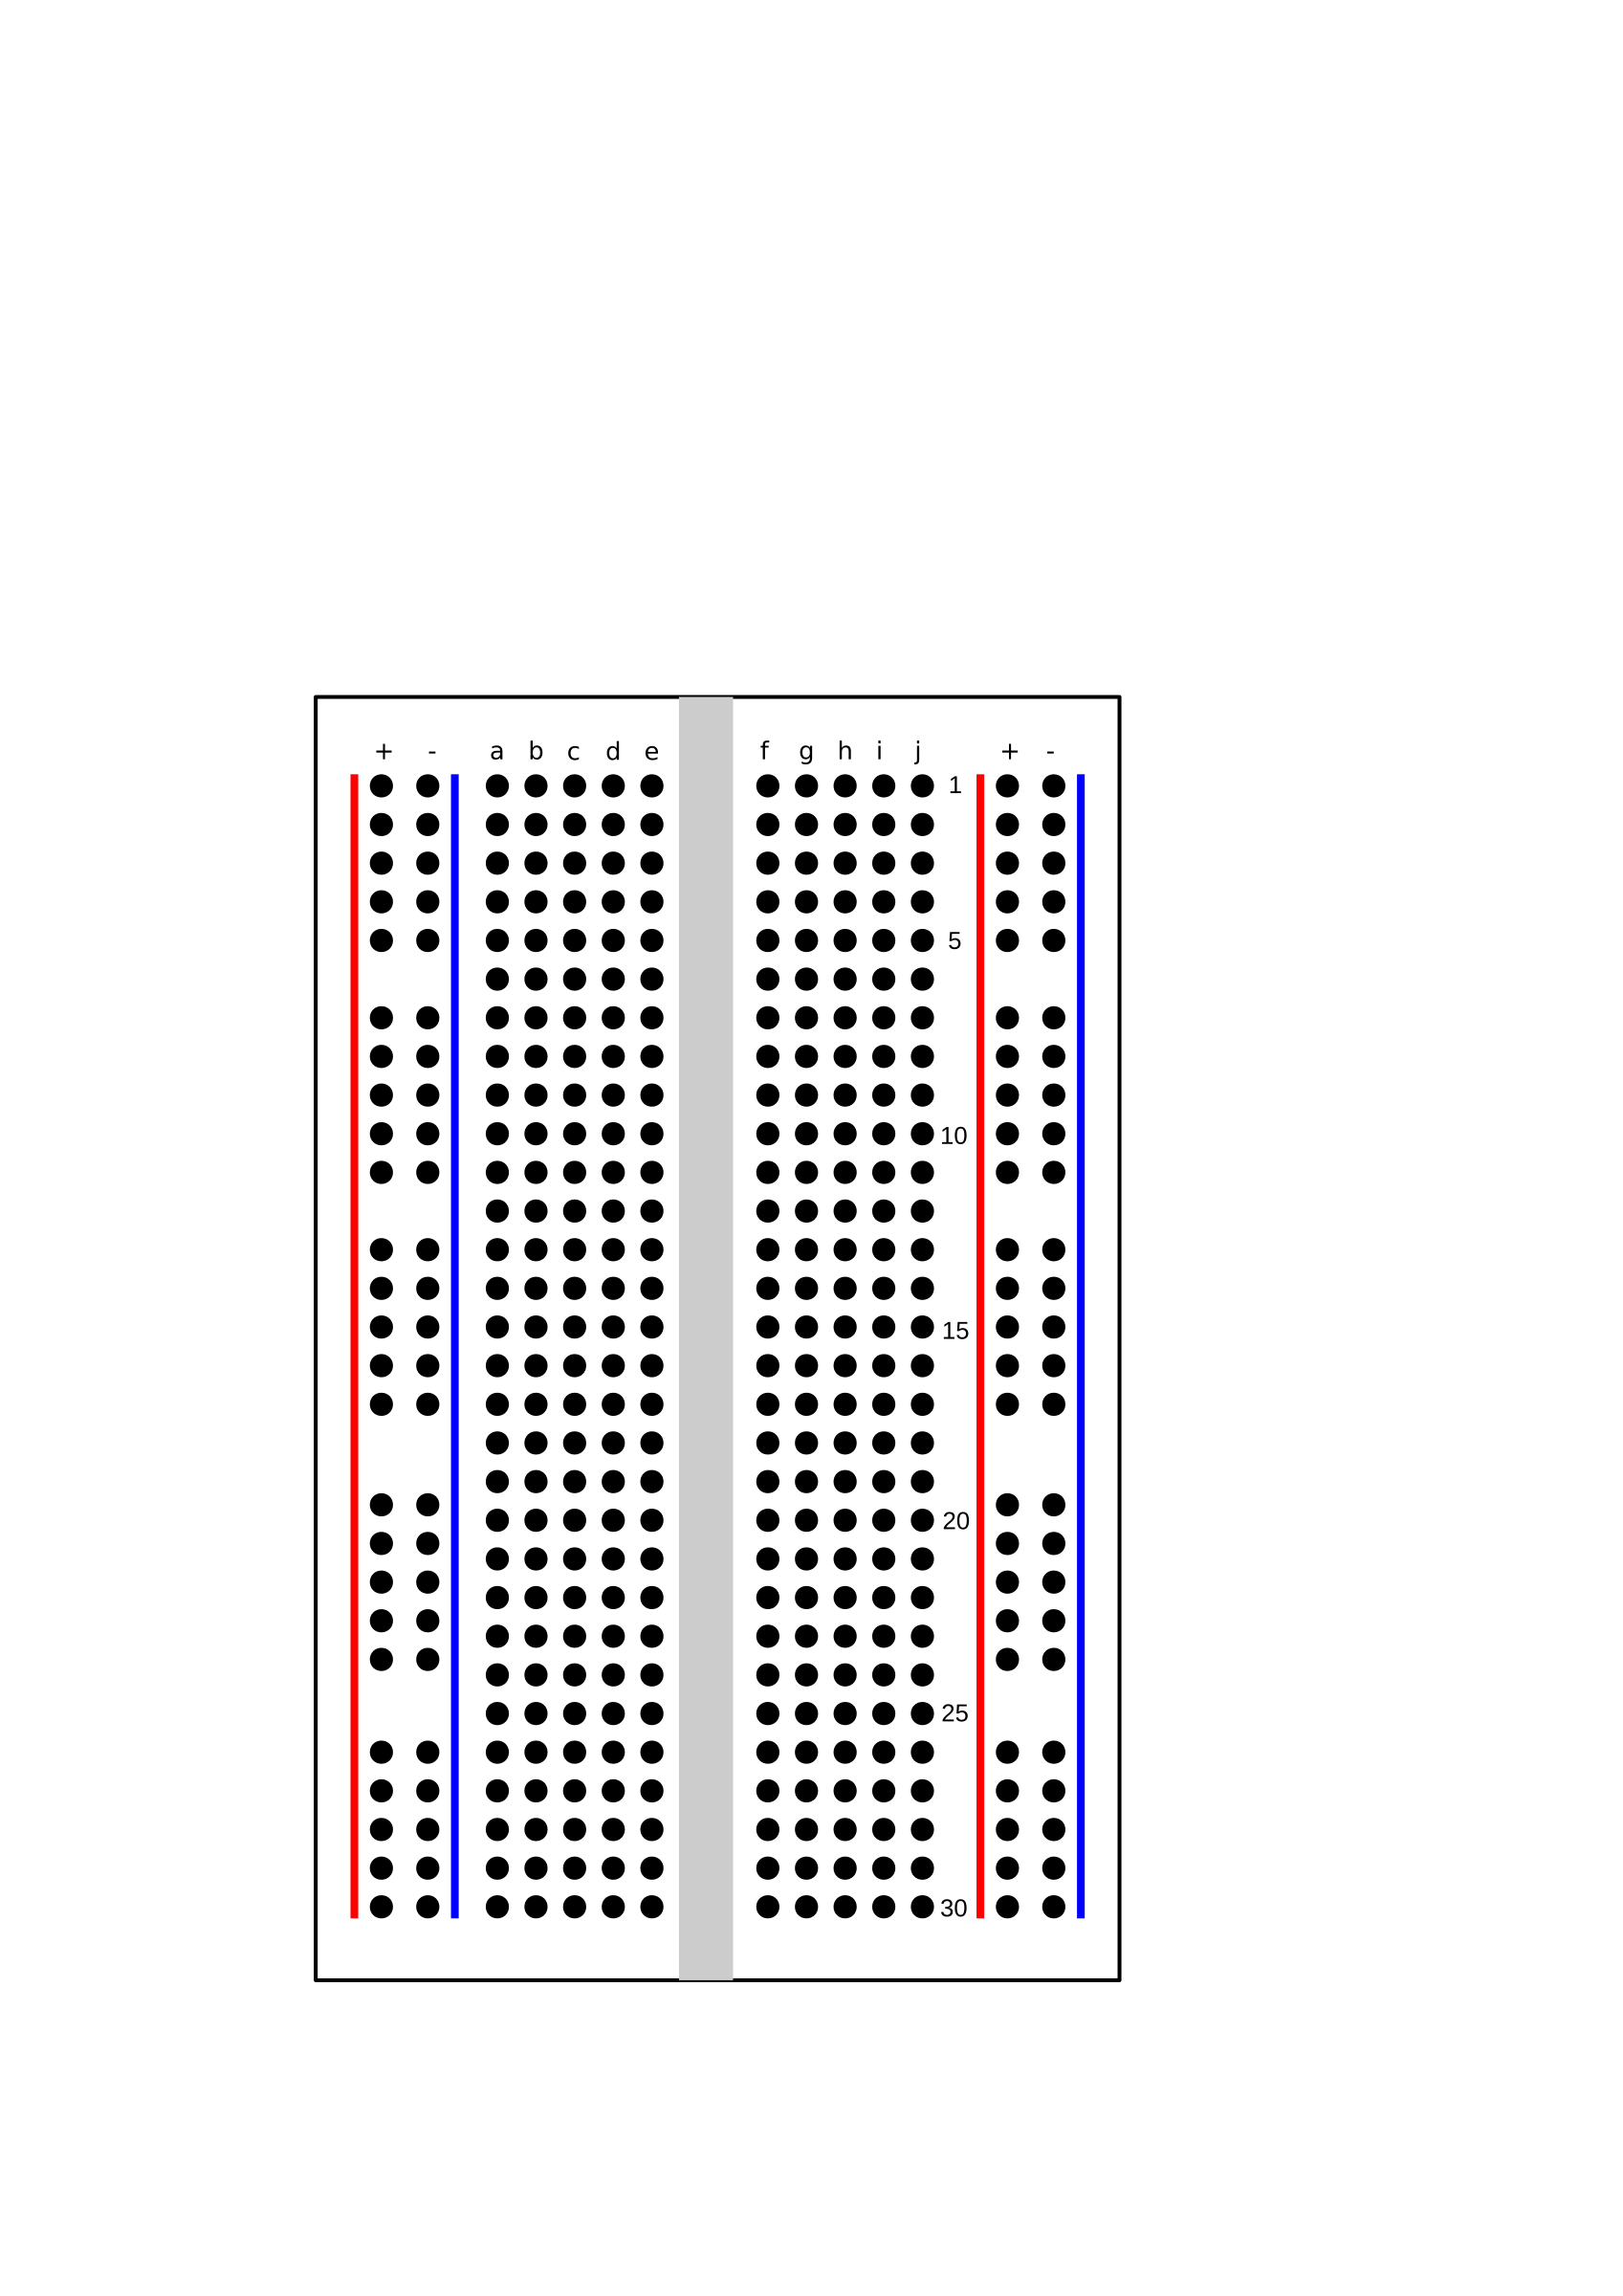

In [68]:
import cv2
import numpy as np
import glob
import os
import base64
import json
from ultralytics import YOLO
from google.colab import files
from IPython.display import HTML, display

# --- 1. 배경 이미지 로드 ---
CLEAN_BREADBOARD_IMG = '/content/clean_breadboard.png'
cb_canvas = cv2.imread(CLEAN_BREADBOARD_IMG)

if cb_canvas is None:
    print("🚨 [오류] 'clean_breadboard.png' 파일을 찾을 수 없습니다. 왼쪽 폴더에 업로드 해주세요.")
else:
    CB_HEIGHT, CB_WIDTH, _ = cb_canvas.shape

    # --- 2. 🌟 빵판 구멍 자동 인식 (글씨 및 기호 완벽 차단) ---
    gray = cv2.cvtColor(cb_canvas, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    temp_holes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        bbox_area = w * h
        contour_area = cv2.contourArea(cnt)

        if h == 0 or w == 0 or contour_area == 0: continue

        aspect_ratio = w / float(h)
        extent = contour_area / float(bbox_area)

        if 20 < bbox_area < 1000 and 0.75 < aspect_ratio < 1.3 and extent > 0.65:
            temp_holes.append({"x": x + w//2, "y": y + h//2, "area": bbox_area})

    holes_data = []
    if not temp_holes:
        print("🚨 [오류] 그림 파일에서 구멍을 전혀 찾지 못했습니다!")
    else:
        median_area = np.median([h['area'] for h in temp_holes])

        for h in temp_holes:
            if median_area * 0.7 < h['area'] < median_area * 1.3:
                holes_data.append({"x": h['x'], "y": h['y'], "net_id": None})

        # --- 3. 🌟 4구역(Zone) 기반 Net 그룹화 및 전원선 구분 ---
        x_coords = [h['x'] for h in holes_data]
        min_x, max_x = min(x_coords), max(x_coords)
        span_x = max_x - min_x

        Z1_END = min_x + span_x * 0.12
        Z2_END = min_x + span_x * 0.48
        Z3_START = min_x + span_x * 0.52
        Z4_START = min_x + span_x * 0.88

        TOL = span_x * 0.015

        net_map = {i: i for i in range(len(holes_data))}
        def find(i):
            if net_map[i] == i: return i
            net_map[i] = find(net_map[i])
            return net_map[i]
        def union(i, j):
            root_i, root_j = find(i), find(j)
            if root_i != root_j: net_map[root_i] = root_j

        for i in range(len(holes_data)):
            for j in range(i+1, len(holes_data)):
                h1, h2 = holes_data[i], holes_data[j]
                dx, dy = abs(h1['x'] - h2['x']), abs(h1['y'] - h2['y'])

                if h1['x'] < Z1_END: z1 = 1
                elif h1['x'] < Z2_END: z1 = 2
                elif h1['x'] > Z4_START: z1 = 4
                elif h1['x'] >= Z3_START: z1 = 3
                else: z1 = 0

                if h2['x'] < Z1_END: z2 = 1
                elif h2['x'] < Z2_END: z2 = 2
                elif h2['x'] > Z4_START: z2 = 4
                elif h2['x'] >= Z3_START: z2 = 3
                else: z2 = 0

                if z1 == z2 and z1 != 0:
                    if z1 == 2 or z1 == 3:
                        if dy < TOL: union(i, j)
                    elif z1 == 1 or z1 == 4:
                        if dx < TOL: union(i, j)

        net_groups = {}
        for i in range(len(holes_data)):
            root = find(i)
            if root not in net_groups:
                net_groups[root] = []
            net_groups[root].append(holes_data[i])

        net_dict = {}
        net_counter = 1

        z1_roots, z4_roots = [], []

        for root, holes in net_groups.items():
            avg_x = sum(h['x'] for h in holes) / len(holes)
            if len(holes) < 3:
                net_dict[root] = f"IGNORE_{root}"
                continue

            if avg_x < Z1_END: z1_roots.append((root, avg_x))
            elif avg_x > Z4_START: z4_roots.append((root, avg_x))
            else:
                net_dict[root] = f"NET_{net_counter:03d}"
                net_counter += 1

        z1_roots.sort(key=lambda item: item[1])
        if len(z1_roots) >= 2:
            net_dict[z1_roots[0][0]] = "LEFT_PWR_+"
            net_dict[z1_roots[-1][0]] = "LEFT_PWR_-"

        z4_roots.sort(key=lambda item: item[1])
        if len(z4_roots) >= 2:
            net_dict[z4_roots[0][0]] = "RIGHT_PWR_+"
            net_dict[z4_roots[-1][0]] = "RIGHT_PWR_-"

        valid_nets = set()
        for i in range(len(holes_data)):
            root = find(i)
            net_name = net_dict.get(root, f"NET_UNK_{root}")
            holes_data[i]['net_id'] = net_name
            if "IGNORE" not in net_name:
                valid_nets.add(net_name)

        print(f"🎯 인식된 구멍: {len(holes_data)}개 / 생성된 회로 라인(Net): {len(valid_nets)}개 (성공!)")

        # --- 4. 🌟 모델 추론 (허공이 아닌 빵판 구멍에 완벽 조준 스폰) ---
        weight_paths = glob.glob('/content/runs/detect/*/weights/best.pt')
        if not weight_paths:
            print("🚨 [오류] 학습된 모델을 찾을 수 없습니다.")
        else:
            trained_model = YOLO(max(weight_paths, key=os.path.getctime))

            print("\n👇 [파일 선택] 버튼을 눌러 실제 빵판 사진을 업로드해주세요!")
            uploaded = files.upload()

            if uploaded:
                real_image_path = list(uploaded.keys())[0]
                real_img = cv2.imread(real_image_path)
                real_h, real_w, _ = real_img.shape

                results = trained_model(real_image_path)
                result = results[0]

                # 💡 [핵심 해결 로직] 캔버스 전체가 아니라 '구멍이 모여있는 실제 빵판 영역'의 바운딩 박스를 계산
                min_hx = min([h['x'] for h in holes_data])
                max_hx = max([h['x'] for h in holes_data])
                min_hy = min([h['y'] for h in holes_data])
                max_hy = max([h['y'] for h in holes_data])

                hole_w = max_hx - min_hx
                hole_h = max_hy - min_hy

                # 사진에 찍힌 빵판의 테두리 여백을 고려하여 구멍 영역보다 약 15% 크게 스케일링
                scale = min(hole_w / real_w, hole_h / real_h) * 1.15

                # 구멍 영역의 '정중앙'에 사진의 정중앙이 오도록 오프셋 계산 (허공 스폰 방지!)
                offset_x = min_hx + (hole_w - (real_w * scale)) / 2
                offset_y = min_hy + (hole_h - (real_h * scale)) / 2

                components_data = []
                for i, box in enumerate(result.boxes):
                    class_name = trained_model.names[int(box.cls[0].item())].lower()
                    xmin, ymin, xmax, ymax = map(int, box.xyxy[0].tolist())

                    cb_xmin = int(xmin * scale + offset_x)
                    cb_ymin = int(ymin * scale + offset_y)
                    cb_w = int((xmax - xmin) * scale)
                    cb_h = int((ymax - ymin) * scale)

                    components_data.append({
                        "id": i, "name": f"{class_name}_{i+1}", "type": class_name,
                        "x": cb_xmin, "y": cb_ymin, "w": cb_w, "h": cb_h
                    })

                with open(CLEAN_BREADBOARD_IMG, "rb") as image_file:
                    encoded_string = base64.b64encode(image_file.read()).decode()
                bg_base64 = f"data:image/png;base64,{encoded_string}"

                json_components = json.dumps(components_data)
                json_holes = json.dumps(holes_data)

                # --- 5. HTML+JS 시뮬레이터 (스냅 기능 포함) ---
                html_code = f"""
                <div style="text-align: center; font-family: sans-serif;">
                    <h3 style="color: #333;">💡 부품이 처음부터 빵판 위에 올라왔나요? 자석 버튼으로 마무리하세요!</h3>

                    <div style="background: #eef; padding: 15px; border-radius: 8px; display: inline-block; margin-bottom: 15px; text-align: left; box-shadow: 2px 2px 5px rgba(0,0,0,0.1);">
                        <strong style="display:block; margin-bottom: 8px; color:#222;">🛠️ 1단계: 미세 조정 (초기 위치가 잘 맞았다면 바로 2단계로!)</strong>
                        <label style="display:inline-block; width: 48%;">↔ 가로 이동: <input type="range" id="shiftX" min="-500" max="500" value="0" oninput="applyGlobalTransform()"></label>
                        <label style="display:inline-block; width: 48%;">↕ 세로 이동: <input type="range" id="shiftY" min="-500" max="500" value="0" oninput="applyGlobalTransform()"></label><br>
                        <label style="display:inline-block; width: 48%;">🔍 전체 크기: <input type="range" id="scaleAll" min="0.3" max="3.0" step="0.05" value="1.0" oninput="applyGlobalTransform()"></label>
                        <label style="display:inline-block; width: 48%;">↔ 가로 폭만: <input type="range" id="scaleX" min="0.5" max="2.0" step="0.05" value="1.0" oninput="applyGlobalTransform()"></label>
                    </div>

                    <div style="display: inline-block; position: relative;">
                        <canvas id="breadboardCanvas" width="{CB_WIDTH}" height="{CB_HEIGHT}"
                                style="border: 2px solid #555; max-width: 100%; height: auto; box-shadow: 2px 2px 10px rgba(0,0,0,0.3);"></canvas>
                    </div>
                    <br>
                    <div style="margin-top: 15px;">
                        <button onclick="snapToGrid()" style="padding: 12px 24px; font-size: 16px; font-weight: bold; cursor: pointer; background-color: #FFA500; color: white; border: none; border-radius: 5px; margin-right: 10px;">
                            🧲 2단계: 구멍에 착! 붙이기 (스냅)
                        </button>
                        <button onclick="generateNetlist()" style="padding: 12px 24px; font-size: 16px; font-weight: bold; cursor: pointer; background-color: #007BFF; color: white; border: none; border-radius: 5px;">
                            ✅ 3단계: 넷리스트 추출
                        </button>
                    </div>
                    <pre id="outputConsole" style="text-align: left; background: #222; color: #0f0; padding: 15px; margin-top: 15px; max-height: 400px; overflow-y: auto; border-radius: 5px; font-size: 15px; width: 80%; margin-left: auto; margin-right: auto; line-height: 1.6;"></pre>
                </div>

                <script>
                    const canvas = document.getElementById('breadboardCanvas');
                    const ctx = canvas.getContext('2d');
                    const outputConsole = document.getElementById('outputConsole');

                    let items = {json_components};
                    let originalItems = JSON.parse(JSON.stringify(items));

                    let holes = {json_holes};
                    let bgImg = new Image();
                    bgImg.src = "{bg_base64}";

                    let isDragging = false, isResizing = false;
                    let dragTarget = null, offsetX, offsetY;
                    const HANDLE_SIZE = 12;

                    let netGroups = {{}};
                    holes.forEach(h => {{
                        if (!netGroups[h.net_id]) netGroups[h.net_id] = [];
                        netGroups[h.net_id].push(h);
                    }});

                    bgImg.onload = () => draw();

                    function applyGlobalTransform() {{
                        let sx = parseInt(document.getElementById('shiftX').value);
                        let sy = parseInt(document.getElementById('shiftY').value);
                        let scale = parseFloat(document.getElementById('scaleAll').value);
                        let scaleX = parseFloat(document.getElementById('scaleX').value);

                        let cx = canvas.width / 2;
                        let cy = canvas.height / 2;

                        for (let i = 0; i < items.length; i++) {{
                            items[i].w = originalItems[i].w * scale * scaleX;
                            items[i].h = originalItems[i].h * scale;
                            items[i].x = (originalItems[i].x - cx) * scale * scaleX + cx + sx;
                            items[i].y = (originalItems[i].y - cy) * scale + cy + sy;
                        }}
                        draw();
                    }}

                    function getNearestHole(px, py) {{
                        let minDist = Infinity, nearest = null;
                        holes.forEach(h => {{
                            let d = Math.hypot(h.x - px, h.y - py);
                            if (d < minDist) {{ minDist = d; nearest = h; }}
                        }});
                        return nearest;
                    }}

                    function snapToGrid() {{
                        items.forEach(item => {{
                            let pins = getPinCoords(item);
                            if (pins.length > 0) {{
                                let nearest = getNearestHole(pins[0].x, pins[0].y);
                                if (nearest) {{
                                    let dx = nearest.x - pins[0].x;
                                    let dy = nearest.y - pins[0].y;
                                    item.x += dx;
                                    item.y += dy;
                                }}
                            }}
                        }});

                        originalItems = JSON.parse(JSON.stringify(items));

                        document.getElementById('shiftX').value = 0;
                        document.getElementById('shiftY').value = 0;
                        document.getElementById('scaleAll').value = 1.0;
                        document.getElementById('scaleX').value = 1.0;

                        draw();
                    }}

                    function draw() {{
                        ctx.clearRect(0, 0, canvas.width, canvas.height);
                        ctx.drawImage(bgImg, 0, 0, canvas.width, canvas.height);

                        ctx.lineWidth = 6;
                        ctx.lineCap = "round";
                        ctx.lineJoin = "round";

                        for (let net in netGroups) {{
                            if (net.includes("IGNORE")) continue;

                            let hList = netGroups[net];
                            if (hList.length > 1) {{
                                let dx = Math.abs(hList[0].x - hList[hList.length-1].x);
                                let dy = Math.abs(hList[0].y - hList[hList.length-1].y);

                                if (dx > dy) hList.sort((a, b) => a.x - b.x);
                                else hList.sort((a, b) => a.y - b.y);

                                if (net.includes("+")) {{
                                    ctx.strokeStyle = "rgba(255, 50, 50, 0.6)";
                                }} else if (net.includes("-")) {{
                                    ctx.strokeStyle = "rgba(50, 50, 255, 0.6)";
                                }} else {{
                                    ctx.strokeStyle = "rgba(0, 220, 50, 0.6)";
                                }}

                                ctx.beginPath();
                                ctx.moveTo(hList[0].x, hList[0].y);
                                for(let i=1; i<hList.length; i++) {{
                                    ctx.lineTo(hList[i].x, hList[i].y);
                                }}
                                ctx.stroke();
                            }}
                        }}

                        items.forEach(item => {{
                            ctx.fillStyle = "rgba(255, 0, 255, 0.15)";
                            ctx.strokeStyle = "rgba(255, 0, 255, 1)";
                            ctx.lineWidth = 2;
                            ctx.fillRect(item.x, item.y, item.w, item.h);
                            ctx.strokeRect(item.x, item.y, item.w, item.h);

                            ctx.fillStyle = "#8B008B";
                            ctx.font = "bold 16px Arial";
                            ctx.fillText(item.name, item.x, item.y - 8);

                            ctx.fillStyle = "red";
                            ctx.fillRect(item.x + item.w - HANDLE_SIZE, item.y + item.h - HANDLE_SIZE, HANDLE_SIZE, HANDLE_SIZE);

                            drawPins(item);
                        }});
                    }}

                    function drawPins(item) {{
                        let pins = getPinCoords(item);
                        pins.forEach(pin => {{
                            let nearest = getNearestHole(pin.x, pin.y);
                            if (nearest) {{
                                ctx.beginPath();
                                ctx.moveTo(pin.x, pin.y); ctx.lineTo(nearest.x, nearest.y);
                                ctx.strokeStyle = "rgba(0,0,0,0.5)"; ctx.setLineDash([5, 5]); ctx.stroke(); ctx.setLineDash([]);

                                ctx.beginPath();
                                ctx.arc(nearest.x, nearest.y, 7, 0, 2 * Math.PI, false);
                                ctx.strokeStyle = "black"; ctx.lineWidth = 2; ctx.stroke();
                            }}

                            ctx.beginPath();
                            ctx.arc(pin.x, pin.y, 6, 0, 2 * Math.PI, false);
                            ctx.fillStyle = pin.color; ctx.fill(); ctx.strokeStyle = 'white'; ctx.stroke();
                        }});
                    }}

                    function getPinCoords(item) {{
                        let pins = [];
                        if (['fet', 'mosfet'].includes(item.type)) {{
                            let mid_x = item.x + (item.w / 2);
                            pins.push({{name: "Source", x: mid_x, y: item.y, color: "blue"}});
                            pins.push({{name: "Drain", x: mid_x, y: item.y + (item.h / 2), color: "green"}});
                            pins.push({{name: "Gate", x: mid_x, y: item.y + item.h, color: "red"}});
                        }} else if (['res', 'led', 'cap', 'jump'].includes(item.type)) {{
                            if (item.w > item.h) {{
                                let mid_y = item.y + (item.h / 2);
                                pins.push({{name: "Pin1", x: item.x, y: mid_y, color: "red"}});
                                pins.push({{name: "Pin2", x: item.x + item.w, y: mid_y, color: "red"}});
                            }} else {{
                                let mid_x = item.x + (item.w / 2);
                                pins.push({{name: "Pin1", x: mid_x, y: item.y, color: "red"}});
                                pins.push({{name: "Pin2", x: mid_x, y: item.y + item.h, color: "red"}});
                            }}
                        }} else {{
                            pins.push({{name: "Pin1", x: item.x, y: item.y + item.h, color: "red"}});
                            pins.push({{name: "Pin2", x: item.x + item.w, y: item.y + item.h, color: "red"}});
                        }}
                        return pins;
                    }}

                    function getMousePos(evt) {{
                        const rect = canvas.getBoundingClientRect();
                        const scaleX = canvas.width / rect.width; const scaleY = canvas.height / rect.height;
                        return {{ x: (evt.clientX - rect.left) * scaleX, y: (evt.clientY - rect.top) * scaleY }};
                    }}

                    canvas.addEventListener('mousedown', function(e) {{
                        const pos = getMousePos(e);
                        for (let i = items.length - 1; i >= 0; i--) {{
                            let item = items[i];
                            if (pos.x >= item.x + item.w - HANDLE_SIZE && pos.x <= item.x + item.w && pos.y >= item.y + item.h - HANDLE_SIZE && pos.y <= item.y + item.h) {{
                                isResizing = true; dragTarget = item; canvas.style.cursor = 'nwse-resize'; return;
                            }}
                            if (pos.x >= item.x && pos.x <= item.x + item.w && pos.y >= item.y && pos.y <= item.y + item.h) {{
                                isDragging = true; dragTarget = item; offsetX = pos.x - item.x; offsetY = pos.y - item.y; canvas.style.cursor = 'grabbing'; return;
                            }}
                        }}
                    }});

                    canvas.addEventListener('mousemove', function(e) {{
                        const pos = getMousePos(e);
                        if (isDragging && dragTarget) {{
                            dragTarget.x = pos.x - offsetX; dragTarget.y = pos.y - offsetY;
                            draw();
                        }}
                        else if (isResizing && dragTarget) {{
                            let newW = pos.x - dragTarget.x; let newH = pos.y - dragTarget.y;
                            if (newW > 20) dragTarget.w = newW; if (newH > 20) dragTarget.h = newH;
                            draw();
                        }}
                    }});

                    canvas.addEventListener('mouseup', function(e) {{
                        isDragging = false; isResizing = false; dragTarget = null; canvas.style.cursor = 'default';
                        originalItems = JSON.parse(JSON.stringify(items));
                    }});

                    canvas.addEventListener('mouseleave', function(e) {{
                        isDragging = false; isResizing = false; dragTarget = null; canvas.style.cursor = 'default';
                    }});

                    function generateNetlist() {{
                        let netlistMap = {{}};

                        items.forEach(item => {{
                            let pins = getPinCoords(item);
                            pins.forEach(pin => {{
                                let nearestHole = getNearestHole(pin.x, pin.y);
                                if (nearestHole && nearestHole.net_id) {{
                                    if (!netlistMap[nearestHole.net_id]) netlistMap[nearestHole.net_id] = [];
                                    netlistMap[nearestHole.net_id].push(`${{item.name}}(${{pin.name}})`);
                                }}
                            }});
                        }});

                        let out = "🔌 [최종 추출된 전기적 회로 넷리스트]\\n\\n";
                        let validConnections = false;

                        out += "🔗 [상호 연결된 노드]\\n";
                        for (let net in netlistMap) {{
                            if (netlistMap[net].length > 1) {{
                                out += `  - ${{net}} :  ${{netlistMap[net].join("  ↔  ")}}\\n`;
                                validConnections = true;
                            }}
                        }}

                        if (!validConnections) out += "  (아직 연결된 부품이 없습니다. 색칠된 선을 공유하도록 다리를 놔주세요!)\\n";

                        out += "\\n📌 [단일 연결 (혼자 꽂힌 핀)]\\n";
                        for (let net in netlistMap) {{
                            if (netlistMap[net].length === 1) {{
                                out += `  - ${{net}} :  ${{netlistMap[net][0]}}\\n`;
                            }}
                        }}

                        outputConsole.innerText = out;
                    }}
                </script>
                """

                display(HTML(html_code))